# Taller Práctico N2 — Diagnóstico preliminar y motor predictivo de riesgo crediticio

**Caso:** Crédito Andino Digital — María Fernanda y el comité directivo.

**Objetivo:** construir un diagnóstico auditable sobre un conjunto de datos público de riesgo
crediticio y entrenar dos modelos supervisados (regresión y clasificación) que sirvan de base
para una recomendación estratégica sobre el umbral de aprobación de créditos.

**Principio rector del taller:** el aprendizaje automático exige transformar los datos en
evidencia confiable *antes* de automatizar decisiones operativas. Por ello, en este notebook
ninguna afirmación se sostiene sobre un supuesto: cada conclusión se deriva de la salida de
una celda ejecutada.

---

## Fases del desarrollo

| Fase | Contenido |
|---|---|
| Paso 0 | Descarga del dataset e inspección del esquema real |
| Fase 1 | Preparación de datos: unidad de análisis, limpieza, codificación y prevención de fugas |
| Fase 2 | Exploración visual y diagnóstico: tipificación de variables y 5 visualizaciones |
| Fase 3 | Modelado supervisado: regresión y clasificación |
| Fase 4 | Evaluación de modelos y recomendación ejecutiva |

# Librerías

In [1]:
import os
import inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, confusion_matrix)

pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', None)

# Semilla

Se fija una semilla única para todo el notebook, de modo que particiones, modelos y cualquier
proceso aleatorio sean reproducibles por el comité al re-ejecutar el análisis.

In [2]:
semilla = 42
np.random.seed(semilla)

# Paso 0 — Carga de datos e inspección del esquema

Fuente: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

Este paso no interpreta ni transforma nada. Su único propósito es **establecer los hechos**:
qué columnas existen, de qué tipo son, cuántos registros hay, dónde faltan datos y cómo se
distribuye la variable objetivo. Todas las decisiones metodológicas de las fases siguientes se
tomarán contra esta evidencia y no contra expectativas previas.

## 0.1 Carga del dataset local

In [3]:
# Usar la copia local del dataset para evitar dependencias y descargas externas
RUTA_DATOS = r"C:\Users\jllr3\Documents\IA\AprendizajeAutomatico\TallerPractico2\datos"
os.makedirs(RUTA_DATOS, exist_ok=True)
path = RUTA_DATOS

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jllr3\Documents\IA\AprendizajeAutomatico\TallerPractico2\datos


In [4]:
# Listar los archivos locales sin asumir el nombre del CSV
archivos = os.listdir(path)

print("=== ARCHIVOS LOCALES ===")
for archivo in archivos:
    tamanio_mb = os.path.getsize(os.path.join(path, archivo)) / (1024 ** 2)
    print(f"  {archivo}  ({tamanio_mb:.2f} MB)")

=== ARCHIVOS DESCARGADOS ===
  credit_risk_dataset.csv  (1.72 MB)


In [5]:
# Tomar el primer archivo .csv encontrado en el directorio local
archivos_csv = [a for a in archivos if a.lower().endswith('.csv')]
ruta_archivo = os.path.join(path, archivos_csv[0])

datos = pd.read_csv(ruta_archivo)

print(f"Archivo cargado: {archivos_csv[0]}")
print(f"Registros: {datos.shape[0]:,}")
print(f"Columnas:  {datos.shape[1]}")

Archivo cargado: credit_risk_dataset.csv
Registros: 32,581
Columnas:  12


## 0.2 Estructura del conjunto de datos

In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [7]:
datos.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 0.3 Calidad de los datos: valores faltantes y duplicados

In [8]:
# Conteo y porcentaje de valores faltantes por columna
nulos = pd.DataFrame({
    'nulos': datos.isna().sum(),
    'porcentaje': (datos.isna().sum() / len(datos) * 100).round(2),
    'tipo_dato': datos.dtypes.astype(str)
})

print("=== VALORES FALTANTES POR COLUMNA ===")
display(nulos.sort_values('nulos', ascending=False))

=== VALORES FALTANTES POR COLUMNA ===


,nulos,porcentaje,tipo_dato
loan_int_rate,3116,9.56,float64
person_emp_length,895,2.75,float64
person_income,0,0.00,int64
person_age,0,0.00,int64
person_home_ownership,0,0.00,str
loan_intent,0,0.00,str
loan_grade,0,0.00,str
loan_amnt,0,0.00,int64
loan_status,0,0.00,int64
loan_percent_income,0,0.00,float64


In [9]:
# Filas completamente idénticas
n_duplicados = datos.duplicated().sum()

print("=== DUPLICADOS ===")
print(f"Filas idénticas: {n_duplicados:,}  ({n_duplicados / len(datos) * 100:.2f}% del total)")
print(f"Registros únicos: {len(datos) - n_duplicados:,}")

=== DUPLICADOS ===
Filas idénticas: 165  (0.51% del total)
Registros únicos: 32,416


## 0.4 Búsqueda de identificador de cliente y de dimensión temporal

Esta evidencia es la que permitirá decidir en la Fase 1 si la unidad de análisis es el cliente
o la solicitud de crédito. Se verifica si existe alguna columna con valores completamente
únicos (candidata a identificador) y si existe alguna columna de tipo fecha.

In [10]:
print("=== CANDIDATAS A IDENTIFICADOR (valores 100% únicos) ===")
candidatas_id = [c for c in datos.columns if datos[c].nunique(dropna=False) == len(datos)]
print(candidatas_id if candidatas_id else "  Ninguna columna tiene valores completamente únicos.")

print("\n=== COLUMNAS DE TIPO FECHA ===")
cols_fecha = datos.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
print(cols_fecha if cols_fecha else "  Ninguna columna fue interpretada como fecha.")

print("\n=== CARDINALIDAD DE CADA COLUMNA ===")
cardinalidad = pd.DataFrame({
    'valores_unicos': datos.nunique(dropna=False),
    'tipo_dato': datos.dtypes.astype(str)
})
display(cardinalidad.sort_values('valores_unicos'))

=== CANDIDATAS A IDENTIFICADOR (valores 100% únicos) ===
  Ninguna columna tiene valores completamente únicos.

=== COLUMNAS DE TIPO FECHA ===
  Ninguna columna fue interpretada como fecha.

=== CARDINALIDAD DE CADA COLUMNA ===


,valores_unicos,tipo_dato
cb_person_default_on_file,2,str
loan_status,2,int64
person_home_ownership,4,str
loan_intent,6,str
loan_grade,7,str
cb_person_cred_hist_length,29,int64
person_emp_length,37,float64
person_age,58,int64
loan_percent_income,77,float64
loan_int_rate,349,float64


## 0.5 Variables categóricas: valores observados

In [11]:
cols_categoricas = datos.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("=== VALORES ÚNICOS DE LAS VARIABLES CATEGÓRICAS ===")
for col in cols_categoricas:
    print(f"\n--- {col}  ({datos[col].nunique()} categorías) ---")
    print(datos[col].value_counts(dropna=False))

=== VALORES ÚNICOS DE LAS VARIABLES CATEGÓRICAS ===

--- person_home_ownership  (4 categorías) ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent  (6 categorías) ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade  (7 categorías) ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file  (2 categorías) ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


## 0.6 Variables numéricas: estadística descriptiva

In [12]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.00,27.73,6.35,20.00,23.00,26.00,30.00,144.00
person_income,32581.00,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.00,4.79,4.14,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.00,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.00,11.01,3.24,5.42,7.90,10.99,13.47,23.22
loan_status,32581.00,0.22,0.41,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.00,0.17,0.11,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.00,5.80,4.06,2.00,3.00,4.00,8.00,30.00


## 0.7 Identificación de la variable objetivo binaria

En lugar de asumir cuál es la columna objetivo, se detectan todas las columnas que solo toman
dos valores distintos y se muestra su distribución. Sobre esa evidencia se confirma cuál
corresponde al indicador de mora.

In [13]:
cols_binarias = [c for c in datos.columns if datos[c].nunique(dropna=True) == 2]

print("=== COLUMNAS BINARIAS DETECTADAS ===")
for col in cols_binarias:
    print(f"\n--- {col} ---")
    frecuencias = pd.DataFrame({
        'frecuencia': datos[col].value_counts(dropna=False),
        'proporcion': (datos[col].value_counts(dropna=False) / len(datos)).round(4)
    })
    print(frecuencias)

=== COLUMNAS BINARIAS DETECTADAS ===



--- loan_status ---
             frecuencia  proporcion
loan_status                        
0                 25473        0.78
1                  7108        0.22

--- cb_person_default_on_file ---
                           frecuencia  proporcion
cb_person_default_on_file                        
N                               26836        0.82
Y                                5745        0.18


## 0.8 Hallazgos del Paso 0

Todo lo que sigue proviene de las salidas ejecutadas en las celdas 0.1 a 0.7.

### Dimensiones y esquema
El archivo `credit_risk_dataset.csv` contiene **32.581 registros y 12 columnas**: 8 numéricas
(5 enteras y 3 de punto flotante) y 4 de texto.

| Columna | Tipo | Valores únicos |
|---|---|---|
| `person_age` | numérica discreta | 58 |
| `person_income` | numérica continua | 4.295 |
| `person_home_ownership` | categórica nominal | 4 |
| `person_emp_length` | numérica discreta | 37 |
| `loan_intent` | categórica nominal | 6 |
| `loan_grade` | categórica ordinal | 7 |
| `loan_amnt` | numérica continua | 753 |
| `loan_int_rate` | numérica continua | 349 |
| `loan_status` | categórica binaria | 2 |
| `loan_percent_income` | numérica continua | 77 |
| `cb_person_default_on_file` | categórica binaria | 2 |
| `cb_person_cred_hist_length` | numérica discreta | 29 |

### Confirmación de las variables objetivo
La celda 0.7 detectó exactamente dos columnas binarias. `loan_status` es el indicador de mora
y será el **objetivo de clasificación**: presenta 25.473 casos en 0 (78%) frente a 7.108 casos
en 1 (22%). Existe por tanto un **desbalance de clases de aproximadamente 3,6 a 1**, hecho que
condicionará la elección de métricas en la fase de evaluación.

`loan_int_rate` es continua, tiene 349 valores distintos y un rango observado de 5,42% a
23,22%. Se confirma como **objetivo de regresión**.

La segunda binaria, `cb_person_default_on_file`, es un antecedente histórico de incumplimiento
del buró de crédito, no el resultado del crédito actual: es un predictor, no un objetivo.

### Calidad de los datos
- **Valores faltantes en dos columnas:** `loan_int_rate` con 3.116 nulos (9,56%) y
  `person_emp_length` con 895 nulos (2,75%). Las diez columnas restantes están completas.
  Es relevante que la variable con más nulos sea justamente el objetivo de regresión.
- **Duplicados:** 165 filas exactamente idénticas (0,51% del total), quedando 32.416 registros
  únicos.

### Ausencia de identificador y de dimensión temporal
La celda 0.4 confirma que **ninguna columna tiene valores completamente únicos** y que
**ninguna columna es de tipo fecha**. Esta es la evidencia que determinará la unidad de
análisis en la Fase 1.

### Anomalías detectadas en la descriptiva
La celda 0.6 revela tres valores máximos que no son consistentes con el resto de la
distribución y que serán cuantificados formalmente en la Fase 1:

- `person_age` alcanza un máximo de **144 años**, frente a una mediana de 26 y un percentil 75
  de 30.
- `person_emp_length` alcanza **123 años de antigüedad laboral**, frente a una mediana de 4.
  El primer registro del dataset ilustra la inconsistencia: 22 años de edad con 123 años de
  experiencia laboral.
- `person_income` alcanza **6.000.000** frente a una mediana de 55.000, con una desviación
  estándar (61.983) casi igual a la media (66.075), lo que anticipa una fuerte asimetría
  positiva.

Estas anomalías se **reportan, no se eliminan todavía**: la decisión de descarte se tomará en
la Fase 1 con criterio estadístico explícito y evidencia a la vista.

### Riesgo de fuga de información ya identificable
`loan_grade` es la calificación de riesgo que la propia institución asigna al crédito, y es
precisamente el insumo con el que se fija la tasa de interés. Usarla para predecir
`loan_int_rate` sería reproducir una regla de negocio, no aprender de los datos. Lo mismo
aplica a `loan_percent_income`, que es una razón derivada de `loan_amnt` y `person_income`.
Ambos casos se contrastarán con el heatmap de correlaciones de la Fase 2 antes de decidir su
exclusión.


# Fase 1 — Preparación de datos

Esta fase convierte el archivo crudo en un conjunto apto para modelar. Cada decisión de
limpieza se toma **después** de cuantificar el problema que la motiva, y se deja registrada
junto a la evidencia que la sustenta.

## 1.1 Definición de la unidad de análisis

La primera pregunta que debe responder el comité es qué representa una fila. De ello depende
si el modelo aprende sobre *personas* o sobre *operaciones*, y qué se le puede preguntar
legítimamente después.

El Paso 0 estableció dos hechos: no existe ninguna columna con valores completamente únicos
(no hay identificador de cliente) y no existe ninguna columna de fecha. A continuación se
agrega una tercera evidencia: cuántas filas comparten exactamente el mismo perfil de persona.

In [14]:
# Atributos que describen a la persona, no al crédito solicitado
cols_persona = [
    'person_age', 'person_income', 'person_home_ownership',
    'person_emp_length', 'cb_person_default_on_file', 'cb_person_cred_hist_length'
]

# Atributos que describen la operación de crédito
cols_credito = ['loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

perfiles_unicos = datos.drop_duplicates(subset=cols_persona).shape[0]
filas_con_perfil_repetido = datos.duplicated(subset=cols_persona, keep=False).sum()

print("=== EVIDENCIA SOBRE LA UNIDAD DE ANÁLISIS ===")
print(f"Total de filas.................................: {len(datos):,}")
print(f"Combinaciones únicas de atributos de persona...: {perfiles_unicos:,}")
print(f"Filas que comparten perfil de persona..........: {filas_con_perfil_repetido:,} "
      f"({filas_con_perfil_repetido / len(datos) * 100:.2f}%)")
print(f"\nColumnas de persona: {cols_persona}")
print(f"Columnas de crédito: {cols_credito}")

=== EVIDENCIA SOBRE LA UNIDAD DE ANÁLISIS ===
Total de filas.................................: 32,581
Combinaciones únicas de atributos de persona...: 29,031
Filas que comparten perfil de persona..........: 6,128 (18.81%)

Columnas de persona: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
Columnas de crédito: ['loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']


### Decisión: la unidad de análisis es la **solicitud de crédito**

La evidencia no permite sostener que cada fila sea un cliente único:

1. **No hay identificador de cliente.** Sin él es imposible agrupar solicitudes por persona.
2. **No hay dimensión temporal.** No se puede ordenar las operaciones de un mismo cliente ni
   construir historial de comportamiento.
3. **Los perfiles de persona se repiten.** Existen menos combinaciones únicas de atributos
   personales que filas totales. Ahora bien, esa repetición es ambigua: puede tratarse del
   mismo cliente con varias solicitudes, o de personas distintas con atributos coincidentes
   (dos personas de 23 años, que alquilan, con ingreso de 50.000 son indistinguibles en este
   dataset). **No hay forma de resolver la ambigüedad con los datos disponibles**, y por eso
   no se intenta desduplicar a nivel persona.

Se adopta entonces la **solicitud de crédito** como unidad de análisis. Cada fila es una
operación evaluada, con el resultado observado de si entró o no en mora.

**Implicaciones que el comité debe conocer:**

- El modelo responde *"¿esta solicitud entrará en mora?"*, **no** *"¿este cliente es riesgoso?"*.
  Es un motor de decisión transaccional, no un scoring de cliente.
- Si un mismo cliente aparece varias veces, sus registros podrían quedar repartidos entre
  entrenamiento y prueba, lo que **optimiza al alza las métricas** respecto de lo que se
  obtendría con clientes verdaderamente nuevos. Es una limitación estructural del dataset, no
  un defecto corregible del modelo, y se retoma en el cierre de auditabilidad.
- No es posible construir variables de comportamiento histórico (mora previa en esta entidad,
  evolución del endeudamiento) porque no hay ni cliente ni tiempo.

## 1.2 Tratamiento de duplicados

Bajo la unidad "solicitud de crédito", dos filas idénticas en las 12 columnas describirían dos
operaciones con el mismo monto, la misma tasa, el mismo destino y el mismo resultado, hechas
por personas de perfil idéntico. Dado que no existe identificador ni fecha que las distinga, no
aportan información nueva al modelo y sí duplican el peso de esos casos en el entrenamiento.
Se eliminan conservando la primera aparición.

In [15]:
n_antes = len(datos)
n_duplicados = datos.duplicated().sum()

datos_limpios = datos.drop_duplicates().reset_index(drop=True)

print("=== TRATAMIENTO DE DUPLICADOS ===")
print(f"Registros antes.......: {n_antes:,}")
print(f"Duplicados eliminados.: {n_duplicados:,} ({n_duplicados / n_antes * 100:.2f}%)")
print(f"Registros después.....: {len(datos_limpios):,}")

# Verificación de que la distribución del objetivo no se alteró
print("\n=== EFECTO SOBRE LA VARIABLE OBJETIVO ===")
comparacion = pd.DataFrame({
    'antes': datos['loan_status'].value_counts(normalize=True).round(4),
    'despues': datos_limpios['loan_status'].value_counts(normalize=True).round(4)
})
print(comparacion)

=== TRATAMIENTO DE DUPLICADOS ===
Registros antes.......: 32,581
Duplicados eliminados.: 165 (0.51%)
Registros después.....: 32,416

=== EFECTO SOBRE LA VARIABLE OBJETIVO ===
             antes  despues
loan_status                
0             0.78     0.78
1             0.22     0.22


## 1.3 Diagnóstico de valores faltantes

El Paso 0 detectó nulos en dos columnas. El tratamiento no puede ser el mismo para ambas,
porque una de ellas es un **predictor** y la otra es el **objetivo del modelo de regresión**:

- `person_emp_length` es un predictor → puede imputarse dentro del Pipeline, calculando el
  estadístico solo sobre el conjunto de entrenamiento.
- `loan_int_rate` es el objetivo de regresión → **imputarlo sería inaceptable**: se estaría
  inventando el valor que el modelo debe aprender a predecir, y las métricas medirían la
  capacidad de reproducir la imputación, no la realidad.

Antes de decidir qué hacer con las filas sin tasa, se verifica si esa ausencia es aleatoria o
si está asociada a algún tipo de solicitud en particular. Si los registros sin tasa tuvieran un
perfil de riesgo distinto, descartarlos sesgaría el análisis.

In [16]:
print("=== VALORES FALTANTES TRAS ELIMINAR DUPLICADOS ===")
nulos_actual = pd.DataFrame({
    'nulos': datos_limpios.isna().sum(),
    'porcentaje': (datos_limpios.isna().sum() / len(datos_limpios) * 100).round(2)
})
display(nulos_actual[nulos_actual['nulos'] > 0])

=== VALORES FALTANTES TRAS ELIMINAR DUPLICADOS ===


,nulos,porcentaje
person_emp_length,887,2.74
loan_int_rate,3095,9.55


In [17]:
# ¿Los registros sin tasa de interés son distintos de los que sí la tienen?
sin_tasa = datos_limpios['loan_int_rate'].isna()

print("=== PERFIL COMPARADO: REGISTROS CON Y SIN TASA DE INTERÉS ===")
print(f"Registros SIN tasa: {sin_tasa.sum():,}")
print(f"Registros CON tasa: {(~sin_tasa).sum():,}")

print("\n--- Tasa de mora (loan_status = 1) ---")
print(f"  En registros SIN tasa: {datos_limpios.loc[sin_tasa, 'loan_status'].mean():.4f}")
print(f"  En registros CON tasa: {datos_limpios.loc[~sin_tasa, 'loan_status'].mean():.4f}")

print("\n--- Comparación de medias en variables numéricas ---")
cols_num = datos_limpios.select_dtypes(include=[np.number]).columns.drop('loan_int_rate')
comparacion_nulos = pd.DataFrame({
    'sin_tasa': datos_limpios.loc[sin_tasa, cols_num].mean(),
    'con_tasa': datos_limpios.loc[~sin_tasa, cols_num].mean()
})
comparacion_nulos['dif_%'] = ((comparacion_nulos['sin_tasa'] / comparacion_nulos['con_tasa'] - 1) * 100).round(2)
display(comparacion_nulos)

print("\n--- Distribución de la calificación de riesgo (loan_grade) ---")
dist_grade = pd.DataFrame({
    'sin_tasa': datos_limpios.loc[sin_tasa, 'loan_grade'].value_counts(normalize=True).round(4),
    'con_tasa': datos_limpios.loc[~sin_tasa, 'loan_grade'].value_counts(normalize=True).round(4)
}).sort_index()
display(dist_grade)

=== PERFIL COMPARADO: REGISTROS CON Y SIN TASA DE INTERÉS ===
Registros SIN tasa: 3,095
Registros CON tasa: 29,321

--- Tasa de mora (loan_status = 1) ---
  En registros SIN tasa: 0.2071
  En registros CON tasa: 0.2199

--- Comparación de medias en variables numéricas ---


,sin_tasa,con_tasa,dif_%
person_age,27.94,27.73,0.77
person_income,66677.88,66029.76,0.98
person_emp_length,4.79,4.79,0.08
loan_amnt,9652.68,9587.64,0.68
loan_status,0.21,0.22,-5.82
loan_percent_income,0.17,0.17,0.67
cb_person_cred_hist_length,5.96,5.80,2.92



--- Distribución de la calificación de riesgo (loan_grade) ---


,sin_tasa,con_tasa
loan_grade,,
A,0.32,0.33
B,0.34,0.32
C,0.20,0.20
D,0.10,0.11
E,0.03,0.03
F,0.01,0.01
G,0.00,0.00


## 1.4 Diagnóstico de valores atípicos

Se cuantifican los atípicos con un criterio estadístico reproducible —el **rango
intercuartílico (IQR)**, con límites en Q1 − 1,5·IQR y Q3 + 1,5·IQR— y por separado se
identifican las **inconsistencias lógicas**, que no dependen de ningún umbral elegido sino de
una contradicción interna entre columnas.

In [18]:
cols_numericas = datos_limpios.select_dtypes(include=[np.number]).columns.drop('loan_status')

resumen_atipicos = []
for col in cols_numericas:
    q1 = datos_limpios[col].quantile(0.25)
    q3 = datos_limpios[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    fuera = ((datos_limpios[col] < lim_inf) | (datos_limpios[col] > lim_sup)).sum()
    resumen_atipicos.append({
        'variable': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lim_inferior': lim_inf, 'lim_superior': lim_sup,
        'atipicos': fuera, 'porcentaje': round(fuera / len(datos_limpios) * 100, 2),
        'maximo_observado': datos_limpios[col].max()
    })

print("=== ATÍPICOS POR CRITERIO IQR (1.5) ===")
display(pd.DataFrame(resumen_atipicos).set_index('variable'))

=== ATÍPICOS POR CRITERIO IQR (1.5) ===


,Q1,Q3,IQR,lim_inferior,lim_superior,atipicos,porcentaje,maximo_observado
variable,,,,,,,,
person_age,23.00,30.00,7.00,12.50,40.50,1491,4.60,144.00
person_income,38542.00,79218.00,40676.00,-22472.00,140232.00,1478,4.56,6000000.00
person_emp_length,2.00,7.00,5.00,-5.50,14.50,852,2.63,123.00
loan_amnt,5000.00,12250.00,7250.00,-5875.00,23125.00,1679,5.18,35000.00
loan_int_rate,7.90,13.47,5.57,-0.46,21.83,6,0.02,23.22
loan_percent_income,0.09,0.23,0.14,-0.12,0.44,650,2.01,0.83
cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,1139,3.51,30.00


In [19]:
print("=== VALORES EXTREMOS OBSERVADOS ===")
print("\nEdades más altas registradas:")
print(datos_limpios['person_age'].sort_values(ascending=False).head(10).to_list())

print("\nAntigüedades laborales más altas registradas:")
print(datos_limpios['person_emp_length'].sort_values(ascending=False).head(10).to_list())

print("\nIngresos más altos registrados:")
print(datos_limpios['person_income'].sort_values(ascending=False).head(10).to_list())

print("\n=== INCONSISTENCIAS LÓGICAS ENTRE COLUMNAS ===")
# Una persona no puede acumular más años de trabajo que años de vida.
incoherentes = datos_limpios['person_emp_length'] > datos_limpios['person_age']
print(f"Registros con antigüedad laboral mayor que la edad: {incoherentes.sum()}")
if incoherentes.sum() > 0:
    display(datos_limpios.loc[incoherentes, ['person_age', 'person_emp_length', 'person_income',
                                             'loan_amnt', 'loan_status']])

=== VALORES EXTREMOS OBSERVADOS ===

Edades más altas registradas:
[144, 144, 144, 123, 123, 94, 84, 80, 78, 76]

Antigüedades laborales más altas registradas:
[123.0, 123.0, 41.0, 38.0, 34.0, 31.0, 31.0, 31.0, 31.0, 30.0]

Ingresos más altos registrados:
[6000000, 2039784, 1900000, 1782000, 1440000, 1362000, 1200000, 1200000, 1200000, 948000]

=== INCONSISTENCIAS LÓGICAS ENTRE COLUMNAS ===
Registros con antigüedad laboral mayor que la edad: 2


,person_age,person_emp_length,person_income,loan_amnt,loan_status
0,22,123.00,59000,35000,1
210,21,123.00,192000,20000,0


## 1.5 Depuración de registros imposibles

Del diagnóstico anterior se desprenden dos tipos de registro que no describen a un cliente
atípico sino un **error de captura**, y solo esos se eliminan:

1. **Contradicción interna entre columnas.** Dos registros declaran más años de antigüedad
   laboral (123) que años de edad (22 y 21). La inconsistencia se detecta sin recurrir a
   ningún criterio externo: basta comparar dos columnas del propio dataset.
2. **Edades biológicamente imposibles.** Se observan edades de 144 y 123 años. El único
   criterio externo empleado en todo el notebook es la máxima longevidad humana documentada
   (122 años, Jeanne Calment), y se declara aquí de forma explícita para que el comité pueda
   auditarlo.

**No se recorta por IQR.** Un ingreso de 6.000.000 o un crédito de 35.000 son estadísticamente
extremos pero perfectamente posibles: eliminarlos borraría precisamente el segmento de clientes
de alto patrimonio y las operaciones de mayor exposición, que son las que más importan al
comité. Los atípicos legítimos se conservan y se tratarán con el escalado.

In [20]:
EDAD_MAXIMA_DOCUMENTADA = 122  # Récord de longevidad humana verificado (Jeanne Calment)

n_antes = len(datos_limpios)

mask_incoherente = datos_limpios['person_emp_length'] > datos_limpios['person_age']
mask_edad_imposible = datos_limpios['person_age'] > EDAD_MAXIMA_DOCUMENTADA
mask_eliminar = mask_incoherente | mask_edad_imposible

print("=== DEPURACIÓN DE REGISTROS IMPOSIBLES ===")
print(f"Antigüedad laboral mayor que la edad.....: {mask_incoherente.sum()}")
print(f"Edad superior a {EDAD_MAXIMA_DOCUMENTADA} años................: {mask_edad_imposible.sum()}")
print(f"Total de registros a eliminar............: {mask_eliminar.sum()}")

datos_modelo = datos_limpios.loc[~mask_eliminar].reset_index(drop=True)

print(f"\nRegistros antes..: {n_antes:,}")
print(f"Registros después: {len(datos_modelo):,}")
print(f"Pérdida total....: {(n_antes - len(datos_modelo)) / n_antes * 100:.3f}% de los datos")

print("\n=== EFECTO SOBRE LA VARIABLE OBJETIVO ===")
print(pd.DataFrame({
    'antes': datos_limpios['loan_status'].value_counts(normalize=True).round(4),
    'despues': datos_modelo['loan_status'].value_counts(normalize=True).round(4)
}))

=== DEPURACIÓN DE REGISTROS IMPOSIBLES ===
Antigüedad laboral mayor que la edad.....: 2
Edad superior a 122 años................: 5
Total de registros a eliminar............: 7

Registros antes..: 32,416
Registros después: 32,409
Pérdida total....: 0.022% de los datos

=== EFECTO SOBRE LA VARIABLE OBJETIVO ===
             antes  despues
loan_status                
0             0.78     0.78
1             0.22     0.22


## 1.6 Roles de las variables

Se declara el rol de cada columna a partir de los tipos y cardinalidades observados en el
Paso 0. Esta declaración gobierna qué transformación recibe cada variable.

In [21]:
# Variables numéricas: reciben imputación (si tienen nulos) y escalado
VAR_NUMERICAS = ['person_age', 'person_income', 'person_emp_length',
                 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']

# Variable ordinal: el orden alfabético de sus categorías coincide con la escala de riesgo
VAR_ORDINAL = ['loan_grade']
ORDEN_GRADE = sorted(datos_modelo['loan_grade'].unique())

# Variables categóricas nominales: sin orden natural
VAR_NOMINALES = ['person_home_ownership', 'loan_intent']

# Variable binaria: se codifica como 0/1
VAR_BINARIA = ['cb_person_default_on_file']

print("=== ROLES DECLARADOS ===")
print(f"Numéricas ({len(VAR_NUMERICAS)}): {VAR_NUMERICAS}")
print(f"Ordinal   ({len(VAR_ORDINAL)}): {VAR_ORDINAL}  ->  orden: {ORDEN_GRADE}")
print(f"Nominales ({len(VAR_NOMINALES)}): {VAR_NOMINALES}")
print(f"Binaria   ({len(VAR_BINARIA)}): {VAR_BINARIA}  ->  valores: {sorted(datos_modelo['cb_person_default_on_file'].unique())}")
print(f"\nObjetivo de clasificación: loan_status")
print(f"Objetivo de regresión.....: loan_int_rate")

# Verificación de que el orden asignado a loan_grade es efectivamente creciente en riesgo
print("\n=== VERIFICACIÓN DEL ORDEN DE loan_grade ===")
print("Si el orden alfabético refleja riesgo creciente, la tasa de mora debe crecer con la letra:")
print(datos_modelo.groupby('loan_grade')['loan_status'].agg(['count', 'mean']).round(4))

=== ROLES DECLARADOS ===
Numéricas (6): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
Ordinal   (1): ['loan_grade']  ->  orden: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Nominales (2): ['person_home_ownership', 'loan_intent']
Binaria   (1): ['cb_person_default_on_file']  ->  valores: ['N', 'Y']

Objetivo de clasificación: loan_status
Objetivo de regresión.....: loan_int_rate

=== VERIFICACIÓN DEL ORDEN DE loan_grade ===
Si el orden alfabético refleja riesgo creciente, la tasa de mora debe crecer con la letra:
            count  mean
loan_grade             
A           10702  0.10
B           10384  0.16
C            6436  0.21
D            3619  0.59
E             963  0.64
F             241  0.71
G              64  0.98


## 1.7 Prevención de fugas de información

Una fuga de información ocurre cuando el modelo recibe, como predictor, un dato que en la
práctica no estaría disponible al momento de decidir, o que es una reexpresión del propio
objetivo. El resultado son métricas excelentes en el laboratorio y un modelo inservible en
producción. Se aplican tres barreras.

### Barrera 1 — Exclusión de predictores contaminados

Para el **modelo de regresión** (objetivo: `loan_int_rate`) se excluyen dos columnas:

- **`loan_grade`**: es la calificación de riesgo que la propia entidad asigna al crédito, y es
  el insumo con el que se fija la tasa. Predecir la tasa a partir del grado no es aprender de
  los datos, sino reproducir una tabla de precios interna. La celda siguiente cuantifica esa
  relación para dejarlo demostrado.
- **`loan_status`**: indica si el crédito terminó en mora, un hecho **posterior** al
  otorgamiento. Al fijar la tasa esa información no existe todavía.

Para el **modelo de clasificación** (objetivo: `loan_status`) no se excluye ninguna variable:
tanto la tasa como el grado se conocen al momento de aprobar la solicitud, que es exactamente
el instante en que el modelo debe operar.

### Barrera 2 — Partición antes de cualquier ajuste

El `train_test_split` se ejecuta **antes** de imputar o escalar. Ningún estadístico del
conjunto de prueba influye sobre el entrenamiento.

### Barrera 3 — Preprocesamiento encapsulado en `Pipeline`

Imputación, escalado y codificación viven dentro de un `Pipeline`, de modo que su `fit` ocurre
únicamente sobre el conjunto de entrenamiento en cada ajuste y evaluación.

In [22]:
print("=== EVIDENCIA DE FUGA: loan_grade DETERMINA loan_int_rate ===")
evidencia_fuga = datos_modelo.groupby('loan_grade')['loan_int_rate'].agg(
    ['count', 'min', 'mean', 'max', 'std']).round(2)
display(evidencia_fuga)

# Correlación entre el grado codificado ordinalmente y la tasa
grade_ordinal = datos_modelo['loan_grade'].map({g: i for i, g in enumerate(ORDEN_GRADE)})
correlacion = grade_ordinal.corr(datos_modelo['loan_int_rate'])

print(f"\nCorrelación de Pearson entre loan_grade (ordinal) y loan_int_rate: {correlacion:.4f}")
print("\nLos rangos de tasa por grado casi no se solapan y la desviación dentro de cada grado")
print("es una fracción de la desviación global. El grado no predice la tasa: la fija.")

=== EVIDENCIA DE FUGA: loan_grade DETERMINA loan_int_rate ===


,count,min,mean,max,std
loan_grade,,,,,
A,9712,5.42,7.33,9.63,1.04
B,9335,6.00,11.00,12.69,0.91
C,5807,6.00,13.46,16.11,0.96
D,3308,6.00,15.36,18.49,1.11
E,880,6.00,17.01,20.69,1.32
F,214,15.01,18.61,22.06,1.38
G,59,17.34,20.25,23.22,1.07



Correlación de Pearson entre loan_grade (ordinal) y loan_int_rate: 0.9337

Los rangos de tasa por grado casi no se solapan y la desviación dentro de cada grado
es una fracción de la desviación global. El grado no predice la tasa: la fija.


## 1.8 Construcción de los dos conjuntos de modelado

Los nulos reciben tratamiento distinto según el papel que juega la columna:

- **`person_emp_length`** (887 nulos, 2,74%) es un **predictor** en ambos modelos. Se imputa
  por la mediana **dentro del Pipeline**, de modo que la mediana se calcule solo con datos de
  entrenamiento.
- **`loan_int_rate`** (3.095 nulos, 9,55%) cambia de papel según el modelo:
  - En **clasificación** es un predictor → se imputa por mediana dentro del Pipeline y se
    conservan todos los registros.
  - En **regresión** es el objetivo → **no puede imputarse**. Imputarlo equivaldría a inventar
    la respuesta que el modelo debe aprender, y el R² mediría la capacidad de reproducir esa
    invención. Esos registros se excluyen únicamente del conjunto de regresión.

El diagnóstico de la sección 1.3 respalda la exclusión: los registros sin tasa presentan una
tasa de mora de 0,2071 frente a 0,2199 en los que sí la tienen, y ninguna variable numérica
difiere más de 3% entre ambos grupos. La ausencia no está asociada al perfil de riesgo, por lo
que descartarlos no introduce sesgo.

In [23]:
# --- Conjunto para CLASIFICACIÓN: todos los registros depurados ---
X_clf = datos_modelo.drop(columns=['loan_status'])
y_clf = datos_modelo['loan_status']

# --- Conjunto para REGRESIÓN: solo registros con tasa observada, sin predictores contaminados ---
datos_reg = datos_modelo.dropna(subset=['loan_int_rate']).reset_index(drop=True)
X_reg = datos_reg.drop(columns=['loan_int_rate', 'loan_grade', 'loan_status'])
y_reg = datos_reg['loan_int_rate']

print("=== CONJUNTO DE CLASIFICACIÓN ===")
print(f"Registros...: {X_clf.shape[0]:,}")
print(f"Predictores.: {X_clf.shape[1]}  ->  {list(X_clf.columns)}")
print(f"Objetivo....: loan_status  (mora = {y_clf.mean():.4f})")

print("\n=== CONJUNTO DE REGRESIÓN ===")
print(f"Registros...: {X_reg.shape[0]:,}  (se excluyen {len(datos_modelo) - len(datos_reg):,} sin tasa observada)")
print(f"Predictores.: {X_reg.shape[1]}  ->  {list(X_reg.columns)}")
print(f"Objetivo....: loan_int_rate  (media = {y_reg.mean():.2f}%, rango {y_reg.min():.2f}% a {y_reg.max():.2f}%)")

=== CONJUNTO DE CLASIFICACIÓN ===
Registros...: 32,409
Predictores.: 11  ->  ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
Objetivo....: loan_status  (mora = 0.2187)

=== CONJUNTO DE REGRESIÓN ===
Registros...: 29,315  (se excluyen 3,094 sin tasa observada)
Predictores.: 9  ->  ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


Objetivo....: loan_int_rate  (media = 11.02%, rango 5.42% a 23.22%)


## 1.9 Partición en entrenamiento y prueba

Se reserva el 20% de cada conjunto para prueba, siguiendo el estándar de los notebooks de
Clase 2. En clasificación la partición es **estratificada**, para que la proporción de mora sea
idéntica en ambos subconjuntos pese al desbalance de 3,6 a 1.

In [24]:
# Clasificación: partición estratificada por la variable objetivo
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=semilla, stratify=y_clf)

# Regresión: partición aleatoria simple
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=semilla)

print("=== PARTICIÓN — CLASIFICACIÓN ===")
print(f"Entrenamiento: {X_clf_train.shape[0]:,} registros  |  mora = {y_clf_train.mean():.4f}")
print(f"Prueba.......: {X_clf_test.shape[0]:,} registros  |  mora = {y_clf_test.mean():.4f}")

print("\n=== PARTICIÓN — REGRESIÓN ===")
print(f"Entrenamiento: {X_reg_train.shape[0]:,} registros  |  tasa media = {y_reg_train.mean():.2f}%")
print(f"Prueba.......: {X_reg_test.shape[0]:,} registros  |  tasa media = {y_reg_test.mean():.2f}%")

=== PARTICIÓN — CLASIFICACIÓN ===
Entrenamiento: 25,927 registros  |  mora = 0.2187
Prueba.......: 6,482 registros  |  mora = 0.2188

=== PARTICIÓN — REGRESIÓN ===
Entrenamiento: 23,452 registros  |  tasa media = 11.02%
Prueba.......: 5,863 registros  |  tasa media = 10.99%


## 1.10 Codificación y ensamblaje del preprocesamiento

Cada tipo de variable recibe la transformación que le corresponde:

| Tipo | Transformación | Justificación |
|---|---|---|
| Numéricas | `SimpleImputer(mediana)` + `StandardScaler` | La mediana resiste la asimetría detectada en ingresos; el escalado sigue el estándar de `Class 2 - Clasificacion` |
| Ordinal (`loan_grade`) | `OrdinalEncoder` con orden A→G | Preserva la escala de riesgo verificada en la sección 1.6 |
| Nominales | `OneHotEncoder(drop='first')` | Sin orden natural; se descarta una categoría para evitar colinealidad perfecta |
| Binaria | `OrdinalEncoder` (N→0, Y→1) | Dos categorías no requieren expansión |

Todo queda dentro de un `ColumnTransformer`, que a su vez se insertará en el `Pipeline` de cada
modelo. Nótese que aquí **solo se define** la transformación: no se ejecuta ningún `fit`. El
ajuste ocurrirá en la Fase 3, sobre el conjunto de entrenamiento exclusivamente.

In [25]:
# Transformación de variables numéricas: imputación por mediana y estandarización
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

# Transformación de la variable ordinal: orden de riesgo A -> G
transformador_ordinal = Pipeline(steps=[
    ('codificador', OrdinalEncoder(categories=[ORDEN_GRADE])),
    ('escalador', StandardScaler())
])

# Transformación de nominales: one-hot descartando la primera categoría
transformador_nominal = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Transformación de la binaria: N -> 0, Y -> 1
ORDEN_BINARIA = sorted(datos_modelo['cb_person_default_on_file'].unique())
transformador_binario = OrdinalEncoder(categories=[ORDEN_BINARIA])


def construir_preprocesador(columnas):
    """Arma el ColumnTransformer usando solo las columnas presentes en el conjunto dado.

    Es necesario porque el conjunto de regresión excluye loan_grade por prevención de fugas,
    mientras que el de clasificación sí lo conserva.
    """
    bloques = []
    num = [c for c in VAR_NUMERICAS if c in columnas]
    ordi = [c for c in VAR_ORDINAL if c in columnas]
    nom = [c for c in VAR_NOMINALES if c in columnas]
    bina = [c for c in VAR_BINARIA if c in columnas]
    extra = [c for c in ['loan_int_rate'] if c in columnas]  # predictor solo en clasificación

    if num or extra:
        bloques.append(('numericas', transformador_numerico, num + extra))
    if ordi:
        bloques.append(('ordinal', transformador_ordinal, ordi))
    if nom:
        bloques.append(('nominales', transformador_nominal, nom))
    if bina:
        bloques.append(('binaria', transformador_binario, bina))

    return ColumnTransformer(transformers=bloques, remainder='drop')


preprocesador_clf = construir_preprocesador(X_clf_train.columns)
preprocesador_reg = construir_preprocesador(X_reg_train.columns)

print("=== PREPROCESADOR — CLASIFICACIÓN ===")
for nombre, _, cols in preprocesador_clf.transformers:
    print(f"  {nombre:12s} -> {cols}")

print("\n=== PREPROCESADOR — REGRESIÓN ===")
for nombre, _, cols in preprocesador_reg.transformers:
    print(f"  {nombre:12s} -> {cols}")

print("\nNingún fit ejecutado todavía: el ajuste ocurre dentro del Pipeline de cada modelo,")
print("exclusivamente sobre el conjunto de entrenamiento.")

=== PREPROCESADOR — CLASIFICACIÓN ===
  numericas    -> ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_int_rate']
  ordinal      -> ['loan_grade']
  nominales    -> ['person_home_ownership', 'loan_intent']
  binaria      -> ['cb_person_default_on_file']

=== PREPROCESADOR — REGRESIÓN ===
  numericas    -> ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']
  nominales    -> ['person_home_ownership', 'loan_intent']
  binaria      -> ['cb_person_default_on_file']

Ningún fit ejecutado todavía: el ajuste ocurre dentro del Pipeline de cada modelo,
exclusivamente sobre el conjunto de entrenamiento.


## 1.11 Cierre de la Fase 1

### Trazabilidad de los registros

| Etapa | Registros | Variación |
|---|---|---|
| Archivo original | 32.581 | — |
| Tras eliminar 165 duplicados exactos | 32.416 | −0,51% |
| Tras eliminar 7 registros imposibles | 32.409 | −0,02% |
| **Conjunto de clasificación** | **32.409** | 100% del depurado |
| **Conjunto de regresión** (con tasa observada) | **29.315** | −3.094 sin tasa |

La depuración total descartó el 0,53% de los datos. Ningún descarte alteró la proporción de la
variable objetivo, que se mantiene en 78% / 22%.

### Resultado: por qué los dos conjuntos tienen distinto tamaño

Las dos últimas filas de la tabla anterior muestran conjuntos de tamaño distinto. La razón es
que `loan_int_rate` **cambia de papel según el modelo**, y ese papel determina si sus 3.094
registros faltantes pueden conservarse o no.

| | Papel de `loan_int_rate` | Tratamiento | Registros |
|---|---|---|---|
| **Clasificación** | Predictor | Se imputa por mediana dentro del Pipeline | 32.409 (todos) |
| **Regresión** | Objetivo | No es imputable: se excluyen | 29.315 |

**Por qué en clasificación se conservan.** Aquí la tasa es una variable de entrada más, conocida
al momento de aprobar la solicitud. Imputar un predictor es una práctica estándar: se sustituye
el dato ausente por la mediana calculada **solo sobre el conjunto de entrenamiento**, dentro del
Pipeline. El registro sigue aportando sus otras diez variables —edad, ingreso, grado, monto,
destino— que son las que realmente sostienen la predicción de mora. Descartarlo por un único
campo faltante significaría perder 3.094 casos con información válida.

**Por qué en regresión se excluyen.** Aquí la tasa es la respuesta que el modelo debe aprender.
Imputarla sería inventar esa respuesta y luego entrenar al modelo para reproducirla: el R²
mediría la capacidad de replicar la mediana imputada, no de estimar la tasa real. Un registro
sin valor observado del objetivo simplemente no enseña nada sobre la relación que se quiere
modelar.

**Por qué excluirlos no sesga el análisis.** La sección 1.3 verificó que la ausencia de tasa no
está asociada al perfil de riesgo: los registros sin tasa presentan una mora de 0,2071 frente a
0,2199 en los que sí la tienen, ninguna variable numérica difiere más de 3% entre ambos grupos,
y la distribución de `loan_grade` es prácticamente idéntica. Si los faltantes se hubieran
concentrado en los créditos más riesgosos, descartarlos habría producido un modelo ciego
justamente al segmento que importa; la evidencia muestra que no es el caso.

### Resultado: la depuración de registros imposibles fue mínima y quirúrgica

De los 32.416 registros sin duplicados, solo **7 (el 0,022%)** resultaron ser errores de
captura demostrables, y esos son los únicos que se eliminaron:

| Criterio | Registros | Naturaleza de la evidencia |
|---|---|---|
| Antigüedad laboral mayor que la edad | 2 | Contradicción **interna** entre dos columnas del propio dataset |
| Edad superior a 122 años | 5 | Único criterio **externo** del notebook, declarado explícitamente |

Los dos registros incoherentes declaran 123 años de antigüedad laboral con 22 y 21 años de
edad respectivamente. Las cinco edades imposibles corresponden a tres registros de 144 años y
dos de 123. El umbral de 122 años es la máxima longevidad humana documentada (Jeanne Calment)
y se dejó como constante nombrada en el código —`EDAD_MAXIMA_DOCUMENTADA`— para que el comité
pueda auditarlo o modificarlo sin buscarlo entre las líneas.

**Lo que deliberadamente no se eliminó.** El criterio IQR habría descartado mucho más: 5,18%
de los registros por `loan_amnt`, 4,60% por `person_age`, 4,56% por `person_income` y 3,51%
por `cb_person_cred_hist_length`. Aplicarlo habría borrado justamente a los clientes de alto
patrimonio —el ingreso máximo observado es 6.000.000 frente a una mediana de 55.000— y a las
operaciones de mayor exposición, que son las que más pesan en la cartera y las que más
importan al comité. Un valor estadísticamente extremo no es un valor erróneo: los atípicos
legítimos se conservan y su escala se neutraliza mediante el escalado del Pipeline, no
mediante el descarte.

Este contraste es en sí mismo un resultado auditable: la diferencia entre depurar 7 registros
y depurar más de 1.600 no es técnica sino de criterio, y queda documentada para que el comité
pueda revisarla.

### Resultado: el orden de `loan_grade` quedó verificado, no supuesto

La sección 1.6 no asumió que A fuera el grado menos riesgoso: lo comprobó contra la tasa de
mora observada, que crece de forma monótona con la letra (A: 10%, B: 16%, C: 21%, D: 59%,
E: 64%, F: 71%, G: 98%). El salto entre C y D es notable —de 21% a 59%— y anticipa que el
grado será un predictor dominante en el modelo de clasificación.

### Resultado: la fuga de información quedó demostrada

La correlación entre `loan_grade` codificado ordinalmente y `loan_int_rate` es **0,9337**, y
los rangos de tasa por grado prácticamente no se solapan (grado A: 5,42% a 9,63%; grado G:
17,34% a 23,22%), con desviaciones internas de aproximadamente 1 punto frente a una desviación
global de 3,24. Esto confirma que el grado no *predice* la tasa sino que la *fija*: es una
regla de negocio, no un patrón a descubrir. Su exclusión del modelo de regresión queda
sustentada en evidencia y no en sospecha.

### Estado al cerrar la fase

Las particiones están hechas y los dos preprocesadores definidos, **sin haber ejecutado un solo
`fit`**. Toda imputación, escalado y codificación ocurrirá dentro del `Pipeline` de cada modelo
en la Fase 3, exclusivamente sobre el conjunto de entrenamiento. Esta es la garantía técnica de
que las métricas que verá el comité no están infladas por contaminación del conjunto de prueba.


# Fase 2 — Exploración visual y diagnóstico

Esta fase responde dos preguntas antes de modelar: **qué tipo de variable es cada columna** y
**qué muestran los datos** sobre patrones, asimetrías, desbalance y riesgo de negocio. Cada
visualización va precedida de una declaración de lo que permite observar, y seguida de la
lectura de lo que efectivamente mostró.

El análisis se hace sobre `datos_modelo`, el conjunto depurado de la Fase 1.

## 2.1 Identificación y clasificación de las variables

Toda variable se clasifica en una de cuatro categorías. El criterio empleado es explícito:

- **Continua**: magnitud que puede tomar cualquier valor dentro de un intervalo (montos,
  tasas, razones). Su cardinalidad es alta respecto del número de registros.
- **Discreta**: cuenta de unidades enteras indivisibles (años cumplidos, años de historial).
  Se verifica empíricamente que la variable solo toma valores enteros.
- **Ordinal**: categoría con orden natural. En la sección 1.6 se comprobó contra la tasa de
  mora que el orden A→G de `loan_grade` es efectivamente creciente en riesgo.
- **Nominal**: categoría sin orden. Se incluye aquí la binaria, caso particular de dos niveles.

In [26]:
# Clasificación declarada de cada variable, con su justificación
TIPOLOGIA = {
    'person_age':                 ('Discreta',  'Años cumplidos: cuenta de unidades enteras'),
    'person_income':              ('Continua',  'Magnitud monetaria anual'),
    'person_home_ownership':      ('Nominal',   'Situación de vivienda sin orden natural'),
    'person_emp_length':          ('Discreta',  'Años de antigüedad laboral'),
    'loan_intent':                ('Nominal',   'Destino del crédito sin orden natural'),
    'loan_grade':                 ('Ordinal',   'Calificación de riesgo A→G, orden verificado en 1.6'),
    'loan_amnt':                  ('Continua',  'Monto del crédito otorgado'),
    'loan_int_rate':              ('Continua',  'Tasa de interés anual en porcentaje'),
    'loan_status':                ('Nominal',   'Binaria: 0 = sin mora, 1 = mora (objetivo)'),
    'loan_percent_income':        ('Continua',  'Razón monto/ingreso, valor entre 0 y 1'),
    'cb_person_default_on_file':  ('Nominal',   'Binaria: antecedente de incumplimiento N/Y'),
    'cb_person_cred_hist_length': ('Discreta',  'Años de historial crediticio'),
}

filas = []
for col, (tipo, justificacion) in TIPOLOGIA.items():
    serie = datos_modelo[col].dropna()
    es_numerica = pd.api.types.is_numeric_dtype(serie)
    filas.append({
        'variable': col,
        'tipo': tipo,
        'dtype': str(datos_modelo[col].dtype),
        'n_unicos': datos_modelo[col].nunique(dropna=False),
        'solo_enteros': bool((serie % 1 == 0).all()) if es_numerica else '-',
        'minimo': serie.min() if es_numerica else '-',
        'maximo': serie.max() if es_numerica else '-',
        'justificacion': justificacion
    })

tipificacion = pd.DataFrame(filas).set_index('variable')

print("=== TIPIFICACIÓN DE VARIABLES ===")
display(tipificacion)

print("\n=== RECUENTO POR TIPO ===")
print(tipificacion['tipo'].value_counts())

# Listas que gobiernan las visualizaciones siguientes
VAR_CONTINUAS = [c for c, (t, _) in TIPOLOGIA.items() if t == 'Continua']
VAR_DISCRETAS = [c for c, (t, _) in TIPOLOGIA.items() if t == 'Discreta']
VAR_ORDINALES = [c for c, (t, _) in TIPOLOGIA.items() if t == 'Ordinal']
VAR_CATEGORICAS = [c for c, (t, _) in TIPOLOGIA.items() if t == 'Nominal']

print(f"\nContinuas...: {VAR_CONTINUAS}")
print(f"Discretas...: {VAR_DISCRETAS}")
print(f"Ordinales...: {VAR_ORDINALES}")
print(f"Nominales...: {VAR_CATEGORICAS}")

=== TIPIFICACIÓN DE VARIABLES ===


,tipo,dtype,n_unicos,solo_enteros,minimo,maximo,justificacion
variable,,,,,,,
person_age,Discreta,int64,56,True,20,94,Años cumplidos: cuenta de unidades enteras
person_income,Continua,int64,4294,True,4000,2039784,Magnitud monetaria anual
person_home_ownership,Nominal,str,4,-,-,-,Situación de vivienda sin orden natural
person_emp_length,Discreta,float64,36,True,0.00,41.00,Años de antigüedad laboral
loan_intent,Nominal,str,6,-,-,-,Destino del crédito sin orden natural
loan_grade,Ordinal,str,7,-,-,-,"Calificación de riesgo A→G, orden verificado e..."
loan_amnt,Continua,int64,753,True,500,35000,Monto del crédito otorgado
loan_int_rate,Continua,float64,349,False,5.42,23.22,Tasa de interés anual en porcentaje
loan_status,Nominal,int64,2,True,0,1,"Binaria: 0 = sin mora, 1 = mora (objetivo)"



=== RECUENTO POR TIPO ===
tipo
Continua    4
Nominal     4
Discreta    3
Ordinal     1
Name: count, dtype: int64

Continuas...: ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
Discretas...: ['person_age', 'person_emp_length', 'cb_person_cred_hist_length']
Ordinales...: ['loan_grade']
Nominales...: ['person_home_ownership', 'loan_intent', 'loan_status', 'cb_person_default_on_file']


## 2.2 Visualización 1 — Distribución de cada variable según su tipo

**Qué permite observar:** la forma de cada variable por separado, antes de relacionarla con
ninguna otra. Para las continuas, un histograma revela asimetría, dispersión y presencia de
colas largas. Para las discretas y categóricas, un diagrama de barras revela qué niveles
concentran los registros y cuáles son marginales.

**Riesgo de negocio que anticipa:** una variable fuertemente asimétrica o con categorías casi
vacías produce modelos inestables en esos tramos. Si el comité va a decidir sobre segmentos con
pocos casos, el modelo tendrá poca evidencia en la que apoyarse justamente ahí.

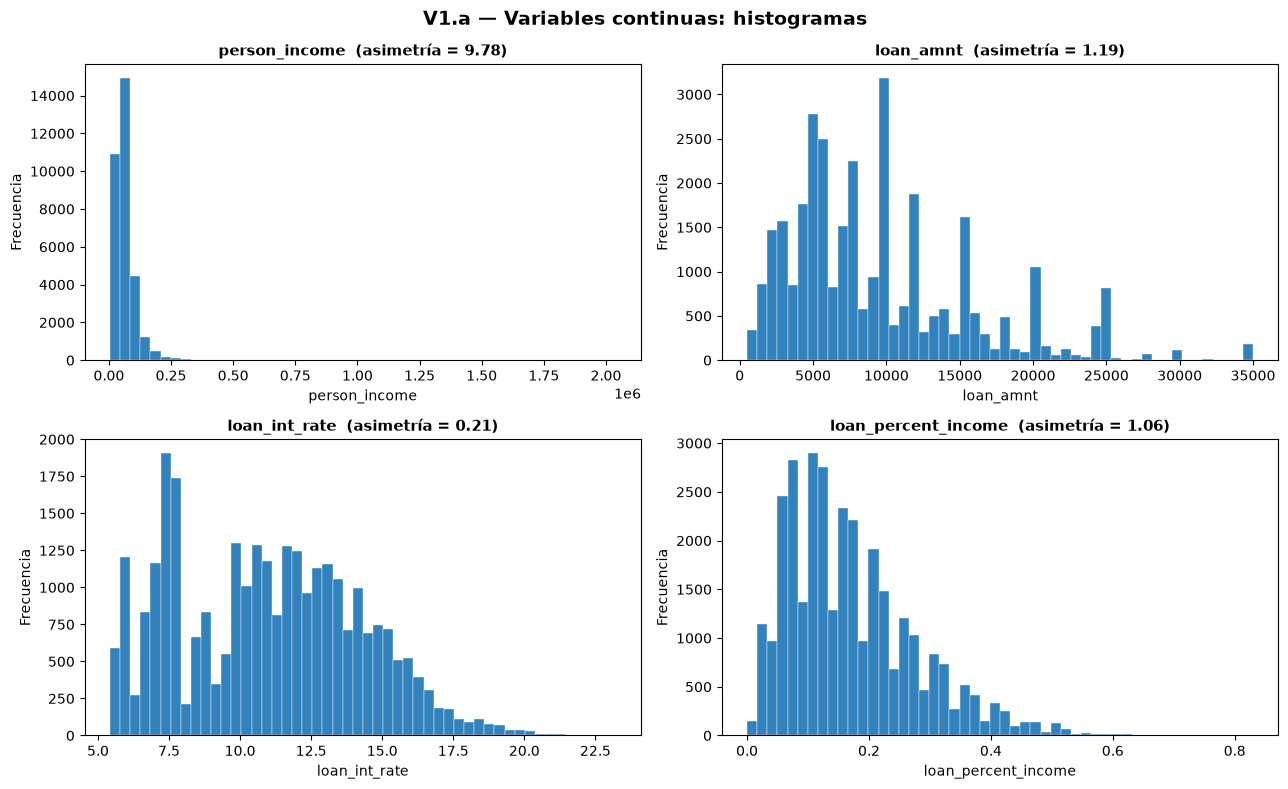

=== ASIMETRÍA (skewness) DE LAS VARIABLES CONTINUAS ===
  person_income           asimetría =    9.78   media =    65,894.28   mediana =    55,000.00
  loan_amnt               asimetría =    1.19   media =     9,592.49   mediana =     8,000.00
  loan_int_rate           asimetría =    0.21   media =        11.02   mediana =        10.99
  loan_percent_income     asimetría =    1.06   media =         0.17   mediana =         0.15


In [27]:
# --- Continuas: histogramas ---
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(13, 8))

for ax, col in zip(axs.ravel(), VAR_CONTINUAS):
    serie = datos_modelo[col].dropna()
    ax.hist(serie, bins=50, color="#3182bd", edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}  (asimetría = {serie.skew():.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

fig.suptitle('V1.a — Variables continuas: histogramas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== ASIMETRÍA (skewness) DE LAS VARIABLES CONTINUAS ===")
for col in VAR_CONTINUAS:
    serie = datos_modelo[col].dropna()
    print(f"  {col:22s}  asimetría = {serie.skew():7.2f}   "
          f"media = {serie.mean():12,.2f}   mediana = {serie.median():12,.2f}")

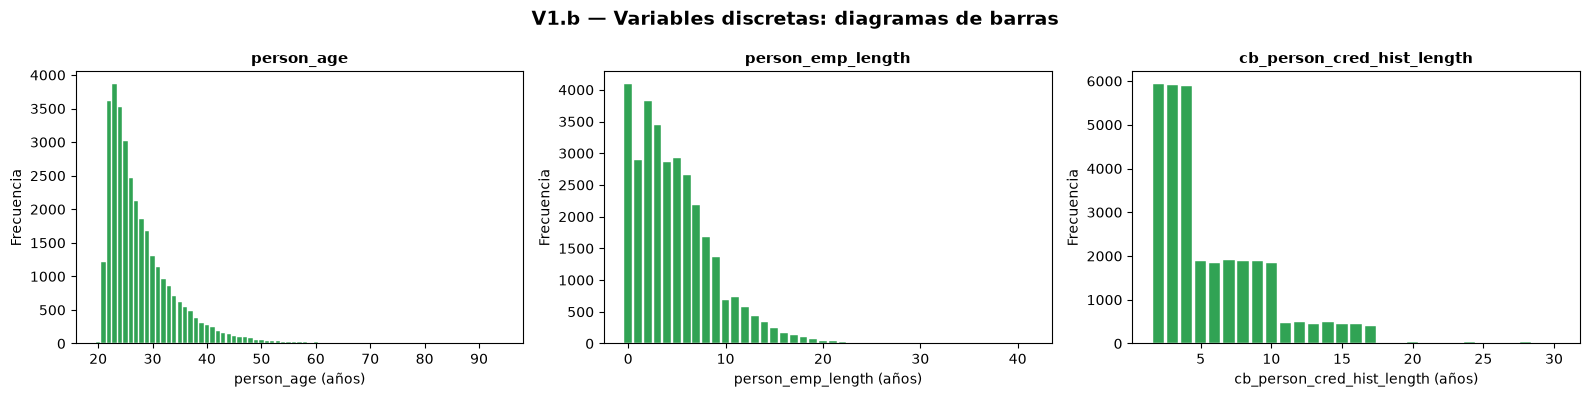

=== CONCENTRACIÓN DE LAS VARIABLES DISCRETAS ===
  person_age                   mediana =  26.0  |  3 valores más frecuentes: {23: np.int64(3861), 22: np.int64(3606), 24: np.int64(3526)}  (33.9% de los registros)
  person_emp_length            mediana =   4.0  |  3 valores más frecuentes: {0.0: np.int64(4086), 2.0: np.int64(3831), 3.0: np.int64(3442)}  (36.0% de los registros)
  cb_person_cred_hist_length   mediana =   4.0  |  3 valores más frecuentes: {2: np.int64(5924), 3: np.int64(5902), 4: np.int64(5879)}  (54.6% de los registros)


In [28]:
# --- Discretas: diagramas de barras ---
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))

for ax, col in zip(axs.ravel(), VAR_DISCRETAS):
    conteo = datos_modelo[col].value_counts().sort_index()
    ax.bar(conteo.index, conteo.values, color="#31a354", edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{col} (años)')
    ax.set_ylabel('Frecuencia')

fig.suptitle('V1.b — Variables discretas: diagramas de barras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== CONCENTRACIÓN DE LAS VARIABLES DISCRETAS ===")
for col in VAR_DISCRETAS:
    serie = datos_modelo[col].dropna()
    top3 = serie.value_counts().head(3)
    print(f"  {col:28s} mediana = {serie.median():5.1f}  |  3 valores más frecuentes: "
          f"{dict(top3)}  ({top3.sum() / len(serie) * 100:.1f}% de los registros)")

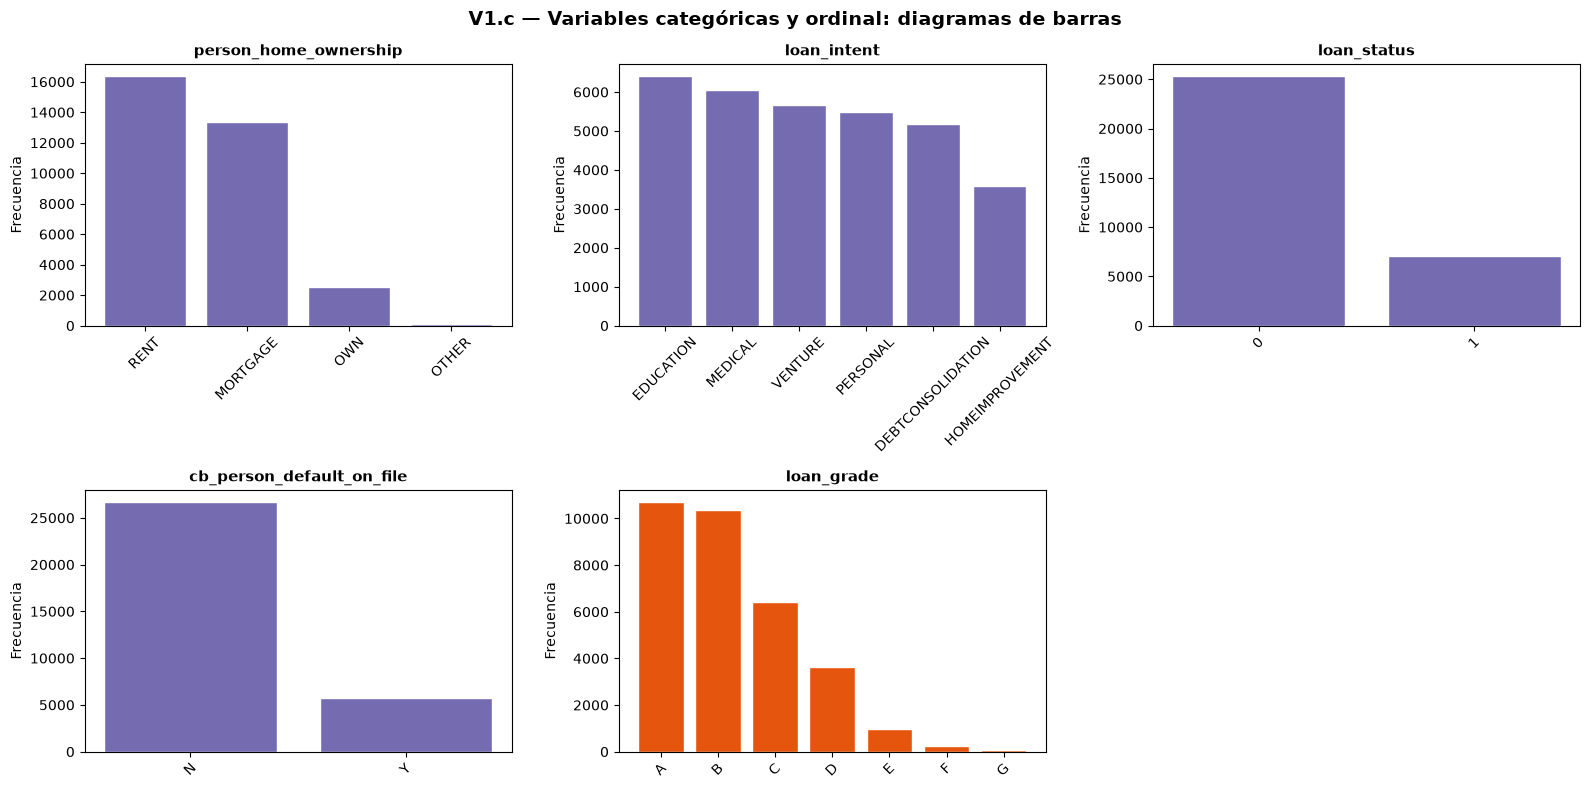

=== PESO RELATIVO DE CADA CATEGORÍA ===

--- person_home_ownership ---
person_home_ownership
RENT       50.52
MORTGAGE   41.24
OWN         7.91
OTHER       0.33

--- loan_intent ---
loan_intent
EDUCATION           19.78
MEDICAL             18.64
VENTURE             17.52
PERSONAL            16.96
DEBTCONSOLIDATION   16.01
HOMEIMPROVEMENT     11.09

--- loan_status ---
loan_status
0   78.13
1   21.87

--- cb_person_default_on_file ---
cb_person_default_on_file
N   82.32
Y   17.68

--- loan_grade ---
loan_grade
A   33.02
B   32.04
C   19.86
D   11.17
E    2.97
F    0.74
G    0.20


In [29]:
# --- Categóricas y ordinal: diagramas de barras ---
cols_barras = VAR_CATEGORICAS + VAR_ORDINALES
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))

for ax, col in zip(axs.ravel(), cols_barras):
    if col in VAR_ORDINALES:
        conteo = datos_modelo[col].value_counts().sort_index()
        color = "#e6550d"
    else:
        conteo = datos_modelo[col].value_counts()
        color = "#756bb1"
    ax.bar(conteo.index.astype(str), conteo.values, color=color, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

for ax in axs.ravel()[len(cols_barras):]:
    ax.axis('off')

fig.suptitle('V1.c — Variables categóricas y ordinal: diagramas de barras',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== PESO RELATIVO DE CADA CATEGORÍA ===")
for col in cols_barras:
    print(f"\n--- {col} ---")
    print((datos_modelo[col].value_counts(normalize=True) * 100).round(2).to_string())

### Lectura de la V1

**Las continuas son marcadamente asimétricas, salvo la tasa.** La asimetría de `person_income`
es **9,78**, un valor extremo: la media (65.894) supera a la mediana (55.000) porque un puñado
de ingresos muy altos arrastra el promedio. `loan_amnt` (1,19) y `loan_percent_income` (1,06)
también sesgan a la derecha. La excepción es `loan_int_rate`, con asimetría de apenas **0,21**
y media prácticamente igual a la mediana (11,02 frente a 10,99): es la única continua que se
comporta de forma casi simétrica, lo que favorece al modelo lineal de la Fase 3.

**La cartera es joven y de historial corto.** Las edades 22, 23 y 24 concentran el **33,9%** de
las solicitudes, con mediana de 26 años. En historial crediticio, los valores 2, 3 y 4 años
reúnen el **54,6%** de los registros. El valor más frecuente de antigüedad laboral es **0 años**
(4.086 solicitudes). El modelo aprenderá sobre todo de clientes jóvenes con trayectoria
crediticia breve.

**Hay categorías marginales que exigen cautela.** En `person_home_ownership`, la categoría
OTHER representa solo el **0,33%**; en `loan_grade`, los grados F y G suman el **0,94%** (0,74%
y 0,20%). Son segmentos con muy pocos casos: cualquier conclusión del modelo sobre ellos se
apoyará en evidencia escasa, y el comité debería tratar esas predicciones con reserva
independientemente de lo que indiquen las métricas globales.

**Un efecto colateral de la depuración.** Tras eliminar los 7 registros imposibles, el ingreso
máximo pasó de 6.000.000 a **2.039.784**, la edad máxima de 144 a **94** años y la antigüedad
laboral máxima de 123 a **41** años. Los valores más extravagantes del dataset provenían
justamente de los registros con error de captura.

## 2.3 Visualización 2 — Distribución teórica que mejor se ajusta a cada variable continua

**Qué permite observar:** qué ley de probabilidad describe cada variable continua. Se ajustan
por máxima verosimilitud cuatro distribuciones candidatas —normal, lognormal, gamma y
exponencial— y se selecciona la de menor **AIC**, criterio que penaliza el número de parámetros
para evitar premiar al modelo simplemente por ser más complejo. Este es el procedimiento del
notebook `Class 2 - Probabilidad`.

**Riesgo de negocio que anticipa:** si una variable resulta lognormal o gamma en lugar de
normal, su cola derecha es pesada: los casos extremos no son anomalías raras sino parte
estructural del fenómeno. Un modelo lineal, que supone errores simétricos, subestimará
sistemáticamente ese tramo — y en una cartera de crédito el tramo alto es el de mayor
exposición.

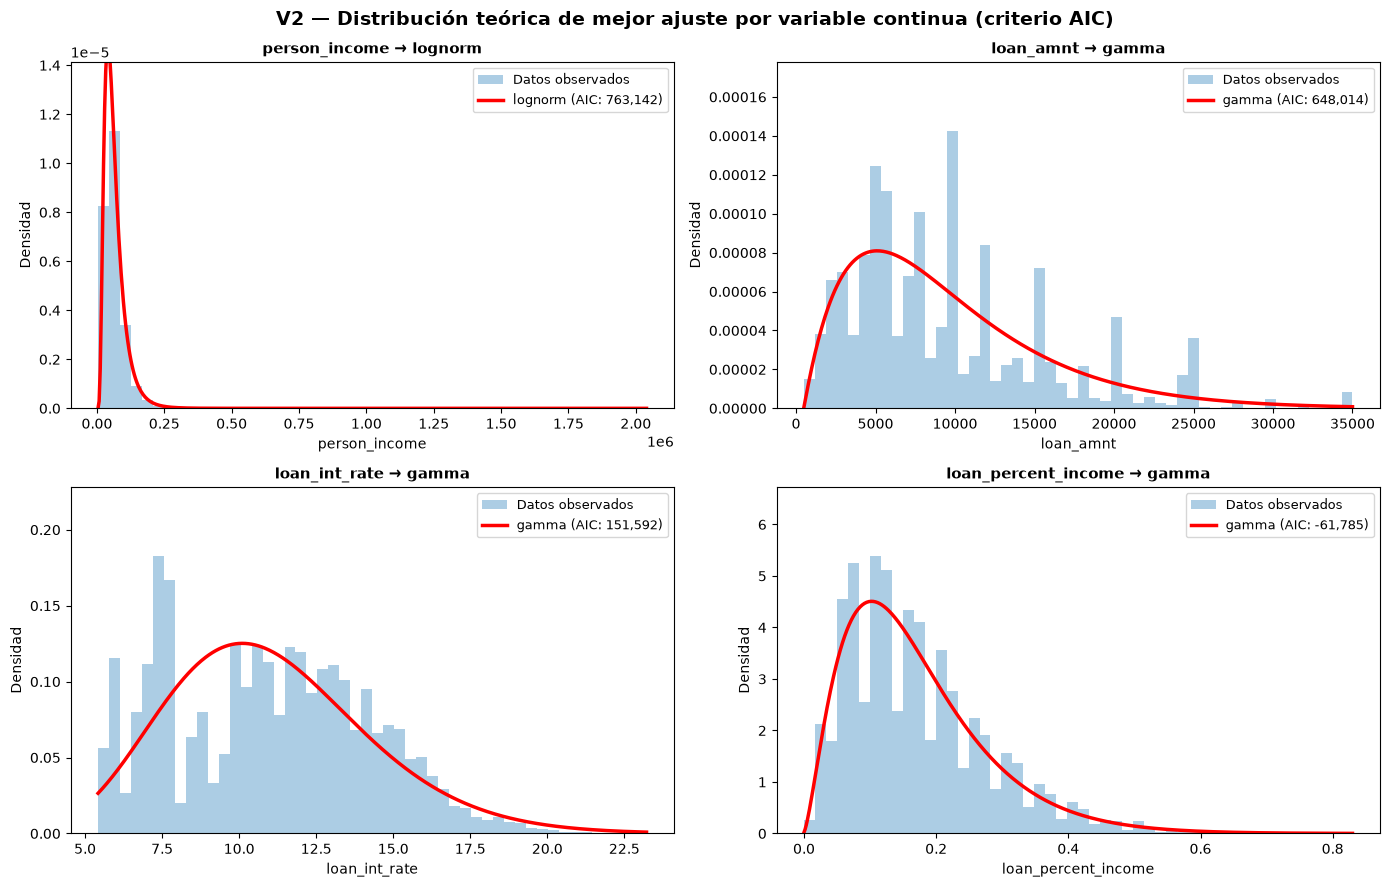

In [30]:
# Distribuciones candidatas, siguiendo Class 2 - Probabilidad
DISTRIBUCIONES = [stats.norm, stats.lognorm, stats.gamma, stats.expon]

resultados_ajuste = []
mejores_ajustes = {}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))

for ax, col in zip(axs.ravel(), VAR_CONTINUAS):
    data = datos_modelo[col].dropna().to_numpy()

    # El histograma en densidad permite superponer la función de densidad teórica
    counts, bins, _ = ax.hist(data, bins=50, density=True, color="#3182bd",
                              alpha=0.4, label='Datos observados')
    x_hat = np.linspace(data.min(), data.max(), num=500)

    ajustes_col = []
    for distribucion in DISTRIBUCIONES:
        try:
            parametros = distribucion.fit(data)
            nombre_parametros = [p for p in inspect.signature(distribucion._pdf).parameters
                                 if p != 'x'] + ["loc", "scale"]
            log_verosimilitud = distribucion.logpdf(data, *parametros).sum()
            k = len(parametros)
            n = len(data)
            aic = -2 * log_verosimilitud + 2 * k
            bic = -2 * log_verosimilitud + np.log(n) * k
        except Exception as e:
            print(f"  [aviso] {distribucion.name} no pudo ajustarse a {col}: {e}")
            continue

        if not np.isfinite(aic):
            continue

        ajustes_col.append({
            'variable': col,
            'distribucion': distribucion.name,
            'log_verosimilitud': log_verosimilitud,
            'AIC': aic,
            'BIC': bic,
            'parametros': tuple(round(p, 4) for p in parametros),
            'nombres_parametros': nombre_parametros,
            'objeto': distribucion
        })

    # Selección por menor AIC
    ajustes_col.sort(key=lambda d: d['AIC'])
    ganadora = ajustes_col[0]
    mejores_ajustes[col] = ganadora
    resultados_ajuste.extend(ajustes_col)

    # Solo se superpone la distribución ganadora
    y_hat = ganadora['objeto'].pdf(x_hat, *ganadora['parametros'])
    ax.plot(x_hat, y_hat, color='red', linewidth=2.5,
            label=f"{ganadora['distribucion']} (AIC: {ganadora['AIC']:,.0f})")

    ax.set_ylim(0, counts.max() * 1.25)
    ax.set_title(f'{col} → {ganadora["distribucion"]}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

fig.suptitle('V2 — Distribución teórica de mejor ajuste por variable continua (criterio AIC)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Tabla comparativa completa de los ajustes
df_ajustes = pd.DataFrame([{k: v for k, v in r.items() if k not in ('objeto', 'nombres_parametros')}
                           for r in resultados_ajuste])
df_ajustes = df_ajustes.sort_values(['variable', 'AIC']).reset_index(drop=True)

print("=" * 75)
print(" AJUSTE DE DISTRIBUCIONES (ordenado por variable y AIC — menor es mejor)")
print("=" * 75)
display(df_ajustes)

print("\n=== DISTRIBUCIÓN SELECCIONADA POR VARIABLE ===")
resumen_ganadoras = []
for col, g in mejores_ajustes.items():
    resumen_ganadoras.append({
        'variable': col,
        'distribucion': g['distribucion'],
        'AIC': round(g['AIC'], 0),
        'parametros': dict(zip(g['nombres_parametros'], g['parametros']))
    })
display(pd.DataFrame(resumen_ganadoras).set_index('variable'))

 AJUSTE DE DISTRIBUCIONES (ordenado por variable y AIC — menor es mejor)


,variable,distribucion,log_verosimilitud,AIC,BIC,parametros
0,loan_amnt,gamma,-324004.24,648014.49,648039.65,"(2.0281, 480.4741, 4492.9633)"
1,loan_amnt,lognorm,-324363.15,648732.31,648757.47,"(0.568, -1473.5517, 9463.2021)"
2,loan_amnt,expon,-327823.64,655651.27,655668.05,"(500.0, 9092.4867)"
3,loan_amnt,norm,-329616.95,659237.91,659254.68,"(9592.4867, 6320.7876)"
4,loan_int_rate,gamma,-75792.97,151591.95,151616.81,"(13.1532, -0.9319, 0.9078)"
5,loan_int_rate,lognorm,-75869.60,151745.19,151770.05,"(0.1394, -12.2971, 23.0894)"
6,loan_int_rate,norm,-76073.16,152150.32,152166.89,"(11.0171, 3.2417)"
7,loan_int_rate,expon,-79802.71,159609.43,159626.00,"(5.42, 5.5971)"
8,loan_percent_income,gamma,30895.62,-61785.23,-61760.08,"(2.5205, -0.0011, 0.068)"
9,loan_percent_income,lognorm,30616.42,-61226.83,-61201.67,"(0.5052, -0.0407, 0.1862)"



=== DISTRIBUCIÓN SELECCIONADA POR VARIABLE ===


,distribucion,AIC,parametros
variable,,,
person_income,lognorm,763142.00,"{'s': 0.5595, 'loc': -474.3309, 'scale': 56122..."
loan_amnt,gamma,648014.00,"{'a': 2.0281, 'loc': 480.4741, 'scale': 4492.9..."
loan_int_rate,gamma,151592.00,"{'a': 13.1532, 'loc': -0.9319, 'scale': 0.9078}"
loan_percent_income,gamma,-61785.00,"{'a': 2.5205, 'loc': -0.0011, 'scale': 0.068}"


### Lectura de la V2

**Ninguna variable continua es normal.** El criterio AIC descartó la distribución normal en
las cuatro:

| Variable | Distribución ganadora | AIC | Segunda mejor |
|---|---|---|---|
| `person_income` | **lognormal** | 763.142 | exponencial (779.971) |
| `loan_amnt` | **gamma** | 648.014 | lognormal (648.732) |
| `loan_int_rate` | **gamma** | 151.592 | lognormal (151.745) |
| `loan_percent_income` | **gamma** | −61.785 | lognormal (−61.227) |

**El ingreso es lognormal, y eso importa.** Es el resultado esperable de una magnitud que se
acumula multiplicativamente, y confirma cuantitativamente lo que la asimetría de 9,78 ya
insinuaba: la cola derecha es estructural, no accidental. Un cliente con ingreso diez veces
superior a la mediana no es un error de captura sino parte del fenómeno. Como el modelo lineal
de la Fase 3 supone errores simétricos, tenderá a equivocarse de forma sistemática en ese
tramo — precisamente el de mayor exposición para la entidad.

**La normal quedó en último lugar para el ingreso**, incluso por detrás de la exponencial
(796.477 frente a 779.971), lo que da la medida de cuán inadecuado sería tratarlo como
gaussiano.

**Matiz sobre `loan_int_rate`.** Aunque la ganadora es la gamma, su parámetro de forma ajustado
es elevado (a = 13,15), y una gamma con forma alta se aproxima a una normal. La diferencia de
AIC frente a la normal (151.592 contra 152.150) es de apenas 558 puntos sobre 29.315
observaciones: la tasa es, en la práctica, la variable más cercana a la simetría del conjunto.
Esto es coherente con su asimetría de 0,21 y sostiene la elección de una regresión lineal para
predecirla.

## 2.4 Visualización 3 — Balance de la variable objetivo

**Qué permite observar:** la proporción real entre créditos que entraron en mora y los que no.

**Riesgo de negocio que anticipa:** con clases desbalanceadas, un modelo que prediga siempre
"sin mora" alcanza una exactitud alta sin haber aprendido nada. Esta gráfica es la que
justifica que el comité **no** evalúe el modelo por su *accuracy*, sino por su capacidad de
detectar la clase minoritaria — que es justamente la costosa.

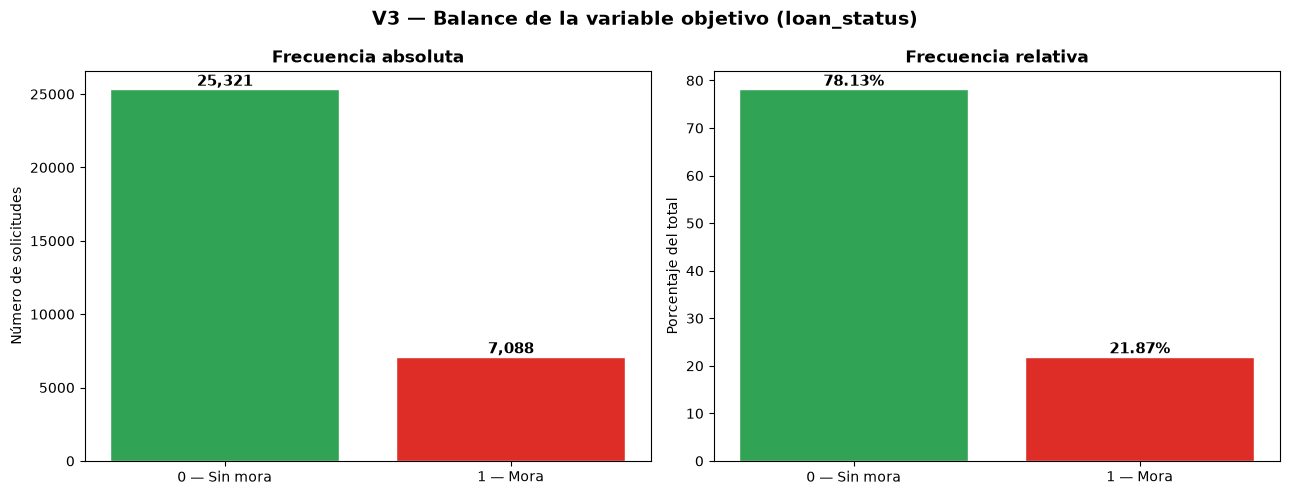

=== DESBALANCE DE CLASES ===
Sin mora (0): 25,321  (78.13%)
Mora (1)....: 7,088  (21.87%)
Razón de desbalance: 3.57 a 1

Exactitud de un modelo trivial que siempre prediga 'sin mora': 78.13%
Cualquier modelo con exactitud inferior a esa cifra es peor que no tener modelo.


In [32]:
conteo_objetivo = datos_modelo['loan_status'].value_counts().sort_index()
proporcion_objetivo = datos_modelo['loan_status'].value_counts(normalize=True).sort_index()
etiquetas = ['0 — Sin mora', '1 — Mora']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

barras = axs[0].bar(etiquetas, conteo_objetivo.values, color=["#31a354", "#de2d26"],
                    edgecolor='white')
axs[0].set_title('Frecuencia absoluta', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Número de solicitudes')
for barra, valor in zip(barras, conteo_objetivo.values):
    axs[0].text(barra.get_x() + barra.get_width() / 2, valor, f'{valor:,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

barras = axs[1].bar(etiquetas, proporcion_objetivo.values * 100,
                    color=["#31a354", "#de2d26"], edgecolor='white')
axs[1].set_title('Frecuencia relativa', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Porcentaje del total')
for barra, valor in zip(barras, proporcion_objetivo.values * 100):
    axs[1].text(barra.get_x() + barra.get_width() / 2, valor, f'{valor:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('V3 — Balance de la variable objetivo (loan_status)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

razon = conteo_objetivo[0] / conteo_objetivo[1]
print("=== DESBALANCE DE CLASES ===")
print(f"Sin mora (0): {conteo_objetivo[0]:,}  ({proporcion_objetivo[0] * 100:.2f}%)")
print(f"Mora (1)....: {conteo_objetivo[1]:,}  ({proporcion_objetivo[1] * 100:.2f}%)")
print(f"Razón de desbalance: {razon:.2f} a 1")
print(f"\nExactitud de un modelo trivial que siempre prediga 'sin mora': "
      f"{proporcion_objetivo[0] * 100:.2f}%")
print("Cualquier modelo con exactitud inferior a esa cifra es peor que no tener modelo.")

### Lectura de la V3

**El desbalance es de 3,57 a 1**: 25.321 solicitudes sin mora (78,13%) frente a 7.088 con mora
(21,87%).

La consecuencia práctica es directa y debe quedar clara ante el comité: **un modelo que
prediga siempre "sin mora", sin analizar nada, acierta el 78,13% de las veces**. Esa cifra es
el piso contra el cual hay que medir cualquier resultado. Una exactitud del 80% no representa
un buen modelo, sino una mejora de menos de dos puntos sobre no tener modelo alguno.

Por eso la evaluación de la Fase 4 no se apoyará en la exactitud sino en la **precisión** y el
**recall de la clase 1**, que miden exactamente lo que interesa: de los créditos que el modelo
marca como riesgosos cuántos lo son realmente, y de los créditos que efectivamente entraron en
mora cuántos logró detectar el modelo. Es también la razón de que la partición de la Fase 1
fuera estratificada: sin ello, la proporción de mora podría diferir entre entrenamiento y
prueba y distorsionar la comparación.

## 2.5 Visualización 4 — Mapa de correlaciones

**Qué permite observar:** la fuerza de la asociación lineal entre cada par de variables
numéricas. Se incluye `loan_grade` codificado ordinalmente para poder examinarlo junto al resto.

**Riesgo de negocio que anticipa:** dos riesgos distintos. El primero es la
**multicolinealidad**: predictores muy correlacionados entre sí vuelven inestables los
coeficientes de la regresión, de modo que pequeñas variaciones en los datos cambian la
interpretación del modelo. El segundo es la **fuga de información**: una correlación
excepcionalmente alta con la variable objetivo suele indicar que el predictor no anticipa el
resultado sino que lo contiene. Esta gráfica es la evidencia visual que respalda las
exclusiones decididas en la sección 1.7.

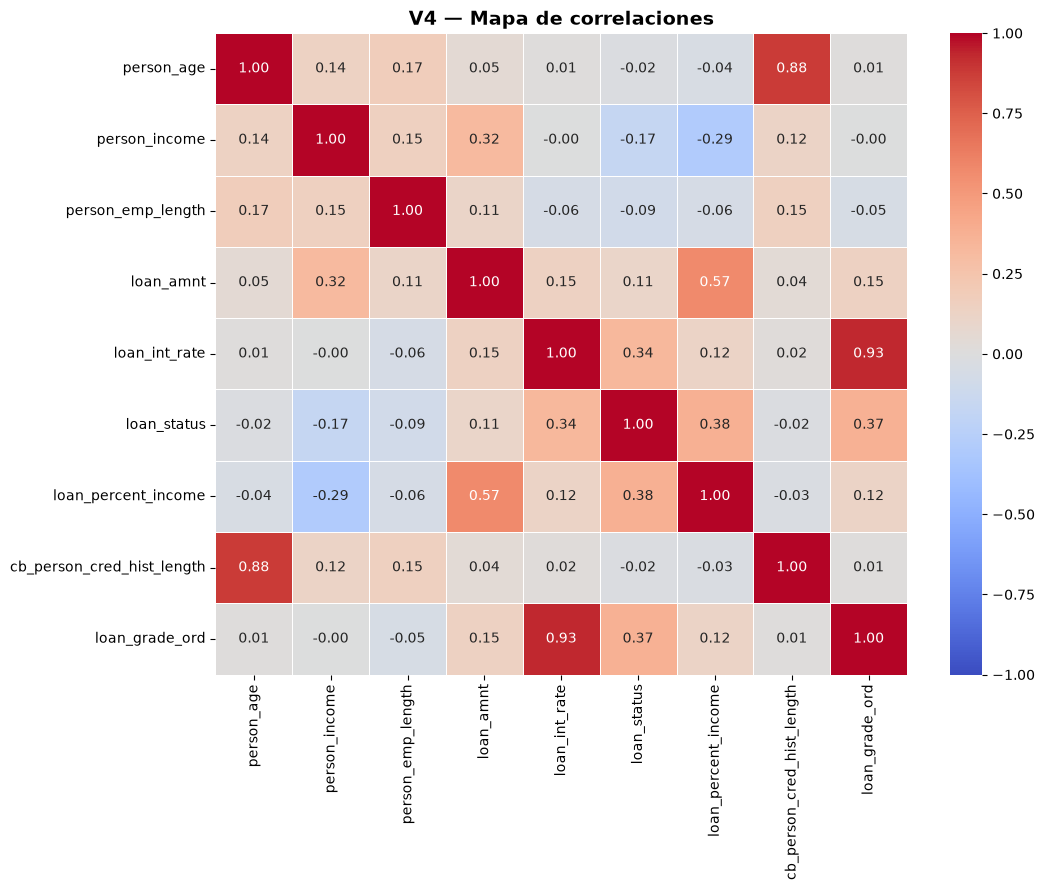

=== CORRELACIONES CON EL OBJETIVO DE REGRESIÓN (loan_int_rate) ===
loan_grade_ord                0.93
loan_status                   0.34
loan_amnt                     0.15
loan_percent_income           0.12
person_emp_length            -0.06
cb_person_cred_hist_length    0.02
person_age                    0.01
person_income                -0.00

=== CORRELACIONES CON EL OBJETIVO DE CLASIFICACIÓN (loan_status) ===
loan_percent_income           0.38
loan_grade_ord                0.37
loan_int_rate                 0.34
person_income                -0.17
loan_amnt                     0.11
person_emp_length            -0.09
person_age                   -0.02
cb_person_cred_hist_length   -0.02

=== PARES DE PREDICTORES CON CORRELACIÓN ABSOLUTA SUPERIOR A 0.5 ===
loan_int_rate  loan_grade_ord               0.93
person_age     cb_person_cred_hist_length   0.88
loan_amnt      loan_percent_income          0.57


In [33]:
# Matriz de correlación sobre numéricas, incorporando loan_grade codificado ordinalmente
datos_corr = datos_modelo.select_dtypes(include=[np.number]).copy()
datos_corr['loan_grade_ord'] = datos_modelo['loan_grade'].map(
    {g: i for i, g in enumerate(ORDEN_GRADE)})

matriz_correlacion = datos_corr.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('V4 — Mapa de correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== CORRELACIONES CON EL OBJETIVO DE REGRESIÓN (loan_int_rate) ===")
print(matriz_correlacion['loan_int_rate'].drop('loan_int_rate')
      .sort_values(key=abs, ascending=False).round(4).to_string())

print("\n=== CORRELACIONES CON EL OBJETIVO DE CLASIFICACIÓN (loan_status) ===")
print(matriz_correlacion['loan_status'].drop('loan_status')
      .sort_values(key=abs, ascending=False).round(4).to_string())

print("\n=== PARES DE PREDICTORES CON CORRELACIÓN ABSOLUTA SUPERIOR A 0.5 ===")
pares = matriz_correlacion.where(np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool)).stack()
pares_altos = pares[abs(pares) > 0.5].sort_values(key=abs, ascending=False)
print(pares_altos.round(4).to_string() if len(pares_altos) else "  Ninguno.")

### Lectura de la V4

**La fuga de información queda confirmada visualmente.** La correlación entre `loan_grade`
codificado ordinalmente y `loan_int_rate` es **0,93**, con diferencia la más alta del mapa.
Ratifica la exclusión decidida en la sección 1.7: el grado no anticipa la tasa, la determina.

**Aparecen dos casos de multicolinealidad entre predictores:**

| Par de variables | Correlación | Implicación |
|---|---|---|
| `person_age` — `cb_person_cred_hist_length` | **0,88** | El historial crediticio crece con la edad; ambas aportan casi la misma información |
| `loan_amnt` — `loan_percent_income` | **0,57** | Esperable: la segunda se calcula a partir de la primera |

La correlación de 0,88 entre edad e historial es la más relevante para la regresión: con
predictores tan alineados, los coeficientes individuales se vuelven inestables y su
interpretación por separado deja de ser confiable. Se conservan ambas variables —la
multicolinealidad afecta la interpretación de los coeficientes, no la capacidad predictiva del
modelo— pero se advierte para que el comité no lea esos dos coeficientes de forma aislada.

**Ninguna variable numérica explica por sí sola la mora.** Las correlaciones más altas con
`loan_status` son `loan_percent_income` (0,38), `loan_grade` (0,37) y `loan_int_rate` (0,34).
Son asociaciones moderadas: no existe un predictor lineal dominante. Esto respalda el uso de un
**árbol de decisión** en la Fase 3, capaz de capturar relaciones no lineales y umbrales
—como el salto de mora entre los grados C y D detectado en la Fase 1— que una frontera lineal
no reproduce.

**Nota metodológica.** El coeficiente de Pearson mide asociación *lineal*. Una correlación baja
no implica ausencia de relación: `person_age` presenta correlación de −0,02 con la mora y aun
así podría discriminar por tramos. Es la razón de complementar este mapa con la V5.

## 2.6 Visualización 5 — Variables numéricas segmentadas por la clase objetivo

**Qué permite observar:** si la distribución de cada variable difiere entre los créditos que
entraron en mora y los que no. Cuando las dos cajas están claramente desplazadas, la variable
tiene poder discriminante; cuando se superponen casi por completo, aporta poco a la decisión.

**Riesgo de negocio que anticipa:** identifica qué característica del solicitante separa
efectivamente a los dos grupos, y por tanto sobre qué señales debería construirse la política
de crédito. Es el diagnóstico más directo del riesgo antes de modelar.

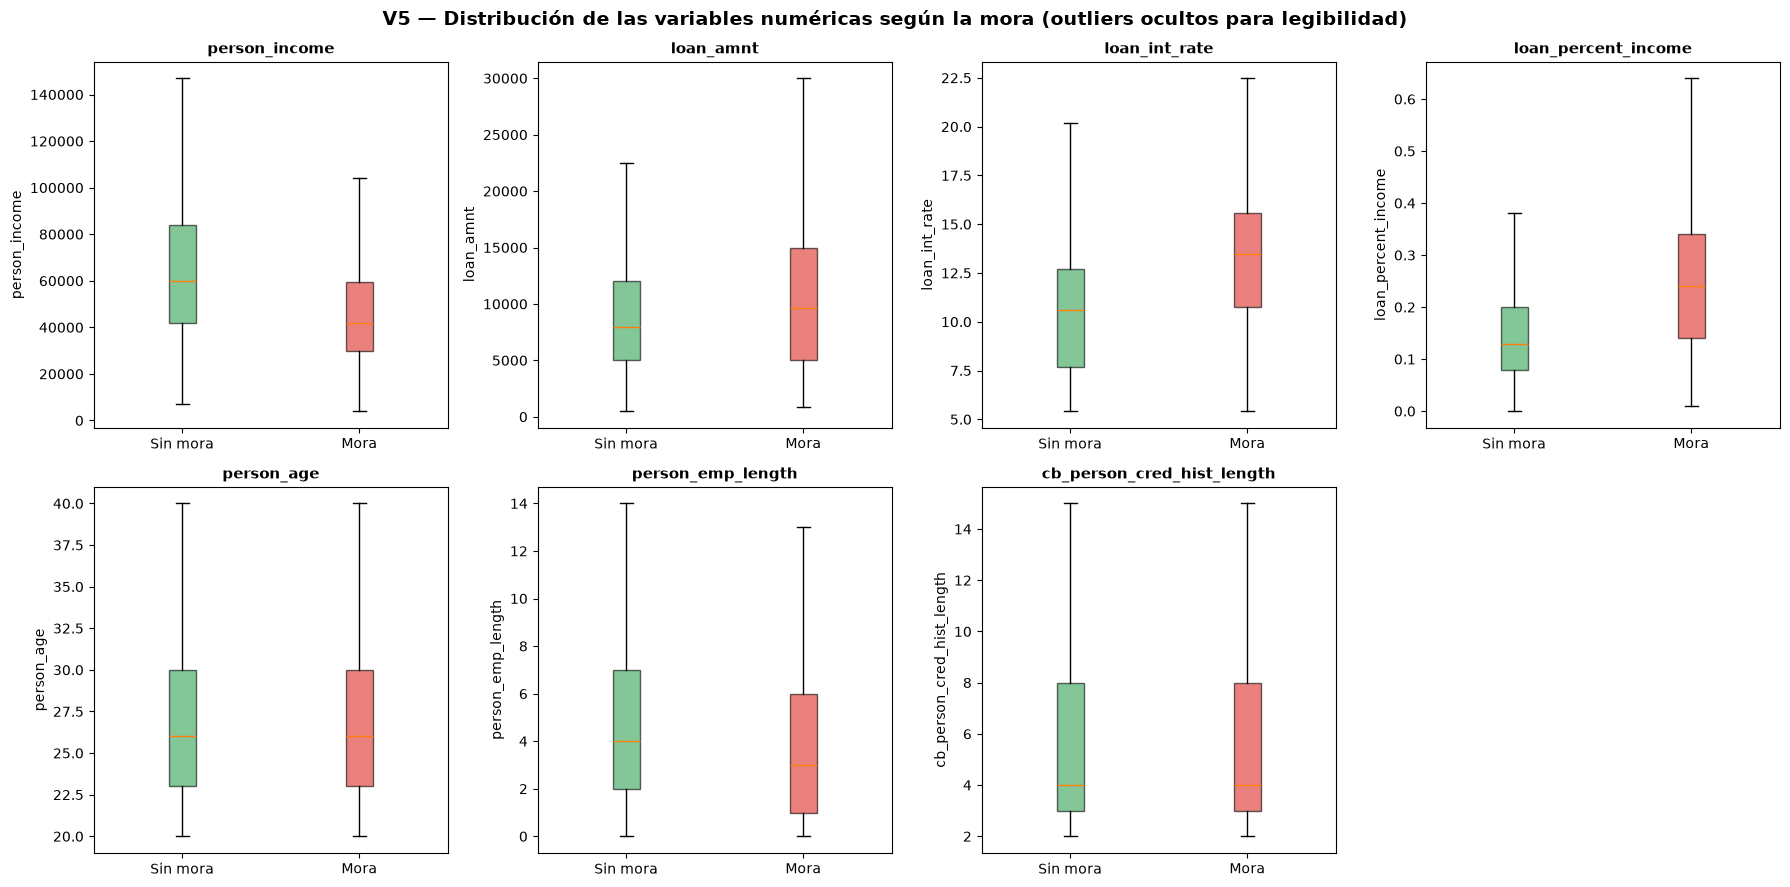

=== COMPARACIÓN DE MEDIANAS ENTRE GRUPOS ===


,sin_mora,mora,diferencia_%
loan_percent_income,0.13,0.24,84.62
person_income,60000.00,41655.00,-30.57
loan_int_rate,10.59,13.49,27.38
person_emp_length,4.00,3.00,-25.00
loan_amnt,8000.00,9600.00,20.00
person_age,26.00,26.00,0.00
cb_person_cred_hist_length,4.00,4.00,0.00


In [34]:
cols_boxplot = VAR_CONTINUAS + VAR_DISCRETAS
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))

for ax, col in zip(axs.ravel(), cols_boxplot):
    datos_box = [datos_modelo.loc[datos_modelo['loan_status'] == 0, col].dropna(),
                 datos_modelo.loc[datos_modelo['loan_status'] == 1, col].dropna()]
    bp = ax.boxplot(datos_box, tick_labels=['Sin mora', 'Mora'], patch_artist=True, showfliers=False)
    for parche, color in zip(bp['boxes'], ["#31a354", "#de2d26"]):
        parche.set_facecolor(color)
        parche.set_alpha(0.6)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)

for ax in axs.ravel()[len(cols_boxplot):]:
    ax.axis('off')

fig.suptitle('V5 — Distribución de las variables numéricas según la mora (outliers ocultos para legibilidad)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== COMPARACIÓN DE MEDIANAS ENTRE GRUPOS ===")
comparacion_grupos = datos_modelo.groupby('loan_status')[cols_boxplot].median().T
comparacion_grupos.columns = ['sin_mora', 'mora']
comparacion_grupos['diferencia_%'] = (
    (comparacion_grupos['mora'] / comparacion_grupos['sin_mora'] - 1) * 100).round(2)
display(comparacion_grupos.sort_values('diferencia_%', key=abs, ascending=False))

### Lectura de la V5

**La carga financiera es el discriminante más fuerte.** La mediana de `loan_percent_income`
pasa de **0,13** en los créditos sanos a **0,24** en los que entraron en mora: un incremento
del **84,62%**, el mayor de todas las variables. Quien compromete cerca de una cuarta parte de
su ingreso en la cuota tiene un perfil de riesgo claramente distinto.

**El resto del ordenamiento por poder discriminante:**

| Variable | Mediana sin mora | Mediana con mora | Diferencia |
|---|---|---|---|
| `loan_percent_income` | 0,13 | 0,24 | **+84,62%** |
| `person_income` | 60.000 | 41.655 | **−30,57%** |
| `loan_int_rate` | 10,59 | 13,49 | **+27,38%** |
| `person_emp_length` | 4 | 3 | −25,00% |
| `loan_amnt` | 8.000 | 9.600 | +20,00% |
| `person_age` | 26 | 26 | 0,00% |
| `cb_person_cred_hist_length` | 4 | 4 | 0,00% |

**El perfil de riesgo que emerge de los datos** combina tres señales: ingreso más bajo
(−30,57%), crédito más grande en términos absolutos (+20%) y, como consecuencia de ambas, una
carga sobre el ingreso mucho mayor. La tasa más alta (+27,38%) es coherente: refleja que la
entidad ya había identificado a esos clientes como más riesgosos al momento de otorgar.

**Dos variables no discriminan en absoluto.** `person_age` y `cb_person_cred_hist_length`
presentan **mediana idéntica** en ambos grupos (26 años y 4 años respectivamente). Esto tiene
dos implicaciones: refuerza que la multicolinealidad de 0,88 entre ambas es poco preocupante
para la clasificación, y anticipa que el árbol las relegará a posiciones secundarias. Es un
hallazgo con contenido de negocio propio: **en esta cartera, la edad no es un criterio de
riesgo**, y una política que discriminara por edad no encontraría respaldo en los datos.

## 2.7 Cierre de la Fase 2

### Qué quedó establecido antes de modelar

**Tipificación completa.** Las 12 variables quedaron clasificadas: 4 continuas, 3 discretas,
1 ordinal y 4 nominales (dos de ellas binarias). Cada asignación se acompañó de su
justificación y se verificó empíricamente si la variable toma solo valores enteros.

**Las distribuciones no son normales.** Ninguna de las cuatro continuas se ajusta mejor a una
normal: tres son gamma y una lognormal. La consecuencia práctica se concentra en
`person_income`, con asimetría de 9,78.

**El desbalance obliga a elegir bien las métricas.** Con 78,13% frente a 21,87%, la exactitud
deja de ser informativa y el criterio de evaluación pasa a ser precisión y recall sobre la
clase minoritaria.

**La fuga de información quedó confirmada.** La correlación de 0,93 entre grado y tasa cierra
la discusión abierta en la sección 1.7.

**El riesgo tiene un perfil identificable.** Carga sobre el ingreso, nivel de ingreso y tasa
asignada separan a los dos grupos; edad e historial crediticio no lo hacen.

### Qué implica para la Fase 3

| Hallazgo de la Fase 2 | Decisión que induce |
|---|---|
| `loan_int_rate` es la continua más simétrica (asimetría 0,21) | Es un objetivo razonable para una regresión lineal |
| `person_income` es lognormal con asimetría 9,78 | La regresión subestimará el tramo alto; debe verificarse en el gráfico de residuos |
| Ninguna correlación lineal con la mora supera 0,38 | Un clasificador lineal sería insuficiente: se justifica el árbol de decisión |
| El salto de mora entre grados C y D es abrupto (21% → 59%) | El árbol debería capturar ese umbral en sus primeras divisiones |
| Los grados F y G suman 0,94% de los registros | Las predicciones sobre esos segmentos tendrán poco respaldo empírico |

# Fase 3 — Modelado supervisado

Se entrenan los dos algoritmos del estándar de Clase 2:

| Modelo | Algoritmo | Objetivo | Pregunta de negocio |
|---|---|---|---|
| Regresión | `LinearRegression` | `loan_int_rate` (continua) | ¿Qué tasa corresponde a esta solicitud según su perfil de riesgo? |
| Clasificación | `DecisionTreeClassifier` | `loan_status` (binaria) | ¿Esta solicitud incurrirá en mora? |

Ambos se entrenan dentro de un `Pipeline` que encapsula el preprocesamiento definido en la
Fase 1. Es aquí donde ocurre el primer y único `fit` de imputadores, escaladores y
codificadores, y ocurre **exclusivamente sobre el conjunto de entrenamiento**.

## 3.1 Modelo de regresión — Tasa de interés

**Utilidad para el comité:** un modelo de *pricing* basado en riesgo. Permite estimar qué tasa
corresponde a una solicitud a partir del perfil del solicitante y las características de la
operación, y detectar créditos cuya tasa vigente se aparta de lo que el perfil justificaría.

Se excluyeron `loan_grade` y `loan_status` como predictores por las razones documentadas en la
sección 1.7: el grado fija la tasa (correlación 0,93) y el estado de mora es información
posterior al otorgamiento.

In [35]:
# Pipeline: preprocesamiento + regresión lineal
modelo_reg = Pipeline(steps=[
    ('preprocesamiento', clone(preprocesador_reg)),
    ('regresion', LinearRegression())
])

modelo_reg.fit(X_reg_train, y_reg_train)

print("=== MODELO DE REGRESIÓN ENTRENADO ===")
print(f"Registros de entrenamiento: {X_reg_train.shape[0]:,}")
print(f"Registros de prueba.......: {X_reg_test.shape[0]:,}")
print(f"Variables tras codificar..: "
      f"{len(modelo_reg.named_steps['preprocesamiento'].get_feature_names_out())}")

=== MODELO DE REGRESIÓN ENTRENADO ===
Registros de entrenamiento: 23,452
Registros de prueba.......: 5,863
Variables tras codificar..: 15


In [36]:
# Coeficientes e intercepto, con el nombre de la variable ya codificada
nombres_variables = modelo_reg.named_steps['preprocesamiento'].get_feature_names_out()
coeficientes = modelo_reg.named_steps['regresion'].coef_
intercepto = modelo_reg.named_steps['regresion'].intercept_

tabla_coef = pd.DataFrame({
    'variable': nombres_variables,
    'coeficiente': coeficientes
}).sort_values('coeficiente', key=abs, ascending=False).reset_index(drop=True)

print("=== COEFICIENTES ===")
display(tabla_coef)

print(f"Intercepto: {intercepto:.4f}")

# R-cuadrado, la medida de desempeño del estándar Class 2 - Regresion
r2_train = modelo_reg.score(X_reg_train, y_reg_train)
r2_test = modelo_reg.score(X_reg_test, y_reg_test)

print("\n=== R-CUADRADO ===")
print(f"R-cuadrado (entrenamiento): {r2_train:.4f}")
print(f"R-cuadrado (prueba).......: {r2_test:.4f}")

=== COEFICIENTES ===


,variable,coeficiente
0,binaria__cb_person_default_on_file,4.12
1,nominales__person_home_ownership_OTHER,1.30
2,nominales__person_home_ownership_RENT,0.84
3,numericas__loan_amnt,0.55
4,nominales__person_home_ownership_OWN,0.40
5,nominales__loan_intent_HOMEIMPROVEMENT,0.13
6,numericas__person_income,-0.11
7,numericas__loan_percent_income,-0.09
8,numericas__person_emp_length,-0.08
9,nominales__loan_intent_VENTURE,-0.07


Intercepto: 9.8374

=== R-CUADRADO ===
R-cuadrado (entrenamiento): 0.2835
R-cuadrado (prueba).......: 0.2904


### Lectura de los coeficientes y el R²

**Advertencia de escala, necesaria para interpretar correctamente la tabla.** Las variables
numéricas fueron estandarizadas, de modo que su coeficiente expresa **el cambio en la tasa por
cada desviación estándar** de la variable. Las categóricas y la binaria no se escalan, así que
su coeficiente expresa el cambio al pasar de una categoría a otra. Los coeficientes de ambos
grupos **no son directamente comparables entre sí** en magnitud.

**El antecedente de incumplimiento domina el precio.** El coeficiente de
`cb_person_default_on_file` es **+4,12**: un solicitante con incumplimiento registrado en el
buró recibe una tasa 4,12 puntos porcentuales más alta que uno sin él, manteniendo lo demás
constante. Es el efecto más grande y el más nítido del modelo.

**La situación de vivienda también pesa.** Tomando la hipoteca como referencia (categoría
descartada por `drop='first'`), alquilar añade **+0,84** puntos, ser propietario **+0,40** y la
categoría OTHER **+1,30** —aunque esta última se apoya en apenas el 0,33% de los registros y
debe leerse con reserva.

**El R² es de 0,2904 en prueba y 0,2835 en entrenamiento.** Dos lecturas:

1. **No hay sobreajuste.** Las cifras son prácticamente iguales, e incluso ligeramente mejor en
   prueba. El modelo generaliza lo que aprendió.
2. **El poder explicativo es bajo, y eso es en sí mismo el hallazgo.** El perfil observable del
   solicitante —edad, ingreso, empleo, monto, destino, vivienda, antecedente— explica solo el
   **29% de la variación** de la tasa. El 71% restante queda fuera del alcance de estas
   variables.

**Por qué el R² bajo confirma lo dicho en la sección 1.7.** No es un fracaso del modelo sino la
consecuencia directa de haber excluido `loan_grade`. Con el grado incluido, el R² se habría
disparado, pero el modelo no habría aprendido nada: solo habría reproducido la tabla de precios
interna de la entidad. Al retirarlo queda a la vista que **la tasa no se deriva del perfil
observable del cliente, sino de una calificación que la entidad asigna con criterios que este
dataset no contiene**. Ese es un resultado relevante para el comité: el precio del crédito hoy
depende de un proceso que no es reconstruible a partir de los datos disponibles.

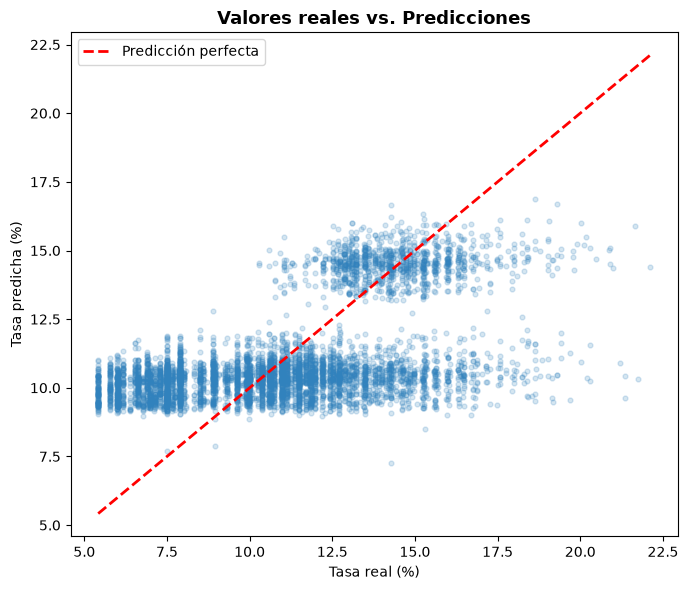

In [37]:
y_reg_pred = modelo_reg.predict(X_reg_test)

# --- Gráfico 1: valores reales frente a predicciones ---
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.2, s=12, color="#3182bd")
limites = [min(y_reg_test.min(), y_reg_pred.min()), max(y_reg_test.max(), y_reg_pred.max())]
plt.plot(limites, limites, 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel("Tasa real (%)")
plt.ylabel("Tasa predicha (%)")
plt.title("Valores reales vs. Predicciones", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

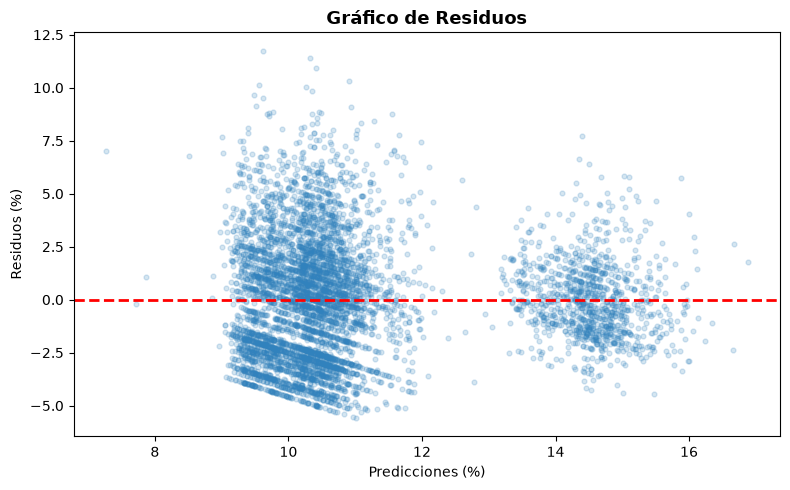

=== ESTADÍSTICA DE LOS RESIDUOS ===
Media...............: -0.0319
Desviación estándar.: 2.7291
Mínimo..............: -5.5885
Máximo..............: 11.7470
Asimetría...........: 0.5153


In [38]:
residuos = y_reg_test - y_reg_pred

# --- Gráfico 2: residuos frente a predicciones ---
plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuos, alpha=0.2, s=12, color="#3182bd")
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicciones (%)")
plt.ylabel("Residuos (%)")
plt.title("Gráfico de Residuos", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== ESTADÍSTICA DE LOS RESIDUOS ===")
print(f"Media...............: {residuos.mean():.4f}")
print(f"Desviación estándar.: {residuos.std():.4f}")
print(f"Mínimo..............: {residuos.min():.4f}")
print(f"Máximo..............: {residuos.max():.4f}")
print(f"Asimetría...........: {residuos.skew():.4f}")

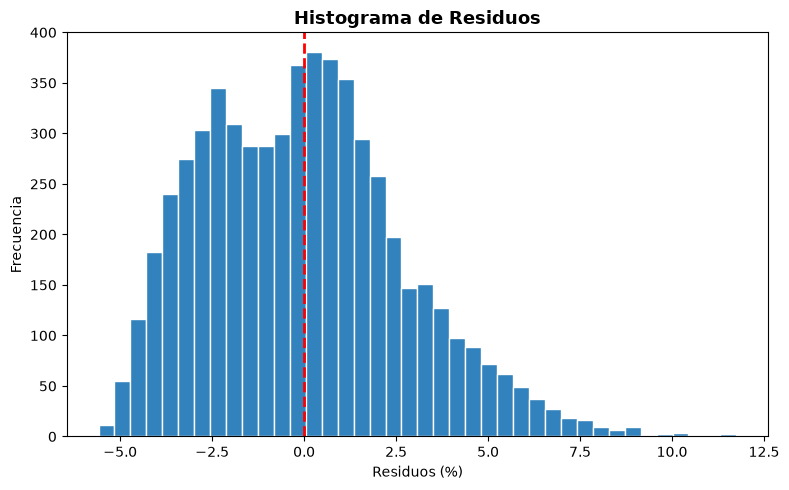

In [39]:
# --- Gráfico 3: histograma de residuos ---
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=40, color="#3182bd", edgecolor='white')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Residuos (%)")
plt.ylabel("Frecuencia")
plt.title("Histograma de Residuos", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Predicción sobre un caso real del conjunto de prueba (sin extrapolar ni fijar coeficientes)
indice_caso = 0
caso = X_reg_test.iloc[[indice_caso]]
tasa_real = y_reg_test.iloc[indice_caso]
tasa_estimada = modelo_reg.predict(caso)[0]

print("=== APLICACIÓN: ESTIMACIÓN DE TASA PARA UNA SOLICITUD ===")
print("\nPerfil de la solicitud:")
for columna, valor in caso.iloc[0].items():
    print(f"  {columna:28s}: {valor}")

print(f"\nTasa realmente aplicada: {tasa_real:.2f}%")
print(f"Tasa estimada por el modelo: {tasa_estimada:.2f}%")
print(f"Diferencia: {tasa_estimada - tasa_real:+.2f} puntos porcentuales")

=== APLICACIÓN: ESTIMACIÓN DE TASA PARA UNA SOLICITUD ===

Perfil de la solicitud:
  person_age                  : 22
  person_income               : 36000
  person_home_ownership       : MORTGAGE
  person_emp_length           : 2.0
  loan_intent                 : VENTURE
  loan_amnt                   : 7750
  loan_percent_income         : 0.22
  cb_person_default_on_file   : N
  cb_person_cred_hist_length  : 4

Tasa realmente aplicada: 9.99%
Tasa estimada por el modelo: 9.68%
Diferencia: -0.31 puntos porcentuales


### Lectura del diagnóstico de residuos y del caso aplicado

**Los residuos no están sesgados, pero sí son asimétricos.** Su media es **−0,0319**,
prácticamente cero: el modelo no sobreestima ni subestima de forma sistemática. Sin embargo, su
asimetría es **0,5153** y el rango es marcadamente desigual: el error va de **−5,59** a
**+11,75** puntos porcentuales. El modelo puede sobreestimar la tasa como mucho en 5,6 puntos,
pero puede quedarse corto hasta en 11,7.

**Esto confirma exactamente lo que anticipó la Fase 2.** Las distribuciones ajustadas mostraron
colas derechas pesadas, y se advirtió que un modelo lineal —que supone errores simétricos—
fallaría en el tramo alto. El histograma de residuos lo verifica: los errores grandes se
concentran en el lado de la subestimación, es decir, en los créditos de tasa elevada. Son
justamente las operaciones de mayor riesgo, y son las que peor estima el modelo.

**Con una desviación estándar de residuos de 2,73 puntos**, el modelo no es apto para fijar
precios por sí solo: un error típico de casi 3 puntos porcentuales es demasiado para una
decisión de *pricing* automática.

**Sí es apto, en cambio, como detector de anomalías.** El caso evaluado —solicitante de 22 años,
ingreso de 36.000, hipoteca, crédito de 7.750 para emprendimiento— recibió una tasa real de
**9,99%** frente a una estimación de **9,68%**, una diferencia de apenas **−0,31 puntos**. Ese
uso es viable: señalar para revisión aquellos créditos cuya tasa vigente se aparta varios puntos
de lo que el perfil justificaría, sin pretender que el modelo fije el precio.

## 3.2 Modelo de clasificación — Probabilidad de mora

**Utilidad para el comité:** el motor de decisión propiamente dicho. Determina si una solicitud
debe aprobarse, rechazarse o derivarse a revisión.

Siguiendo el estándar de `Class 2 - Clasificacion`, se entrenan **dos versiones del mismo
algoritmo** para hacer visible el efecto del sobreajuste:

1. Un árbol **sin restricciones**, que crece hasta agotar la información del conjunto de
   entrenamiento.
2. Un árbol **podado**, con los mismos hiperparámetros del notebook de clase
   (`max_depth=3`, `min_samples_split=20`, `min_samples_leaf=10`).

A diferencia de la regresión, aquí **no se excluye ninguna variable**: tanto la tasa como el
grado se conocen al momento de aprobar la solicitud, que es el instante exacto en que este
modelo debe operar.

### 3.2.1 Modelo 1 — Árbol sin poda

In [41]:
arbol_clf = Pipeline(steps=[
    ('preprocesamiento', clone(preprocesador_clf)),
    ('arbol', DecisionTreeClassifier(random_state=semilla))
])

arbol_clf.fit(X_clf_train, y_clf_train)

estructura = arbol_clf.named_steps['arbol']

print("=== ESTRUCTURA DEL ÁRBOL ===")
print(f"Profundidad máxima alcanzada: {estructura.get_depth()}")
print(f"Número total de nodos terminales (hojas): {estructura.get_n_leaves()}")
print(f"Registros de entrenamiento: {X_clf_train.shape[0]:,}")
print(f"\nPromedio de registros por hoja: "
      f"{X_clf_train.shape[0] / estructura.get_n_leaves():.2f}")

=== ESTRUCTURA DEL ÁRBOL ===
Profundidad máxima alcanzada: 29
Número total de nodos terminales (hojas): 2193
Registros de entrenamiento: 25,927

Promedio de registros por hoja: 11.82


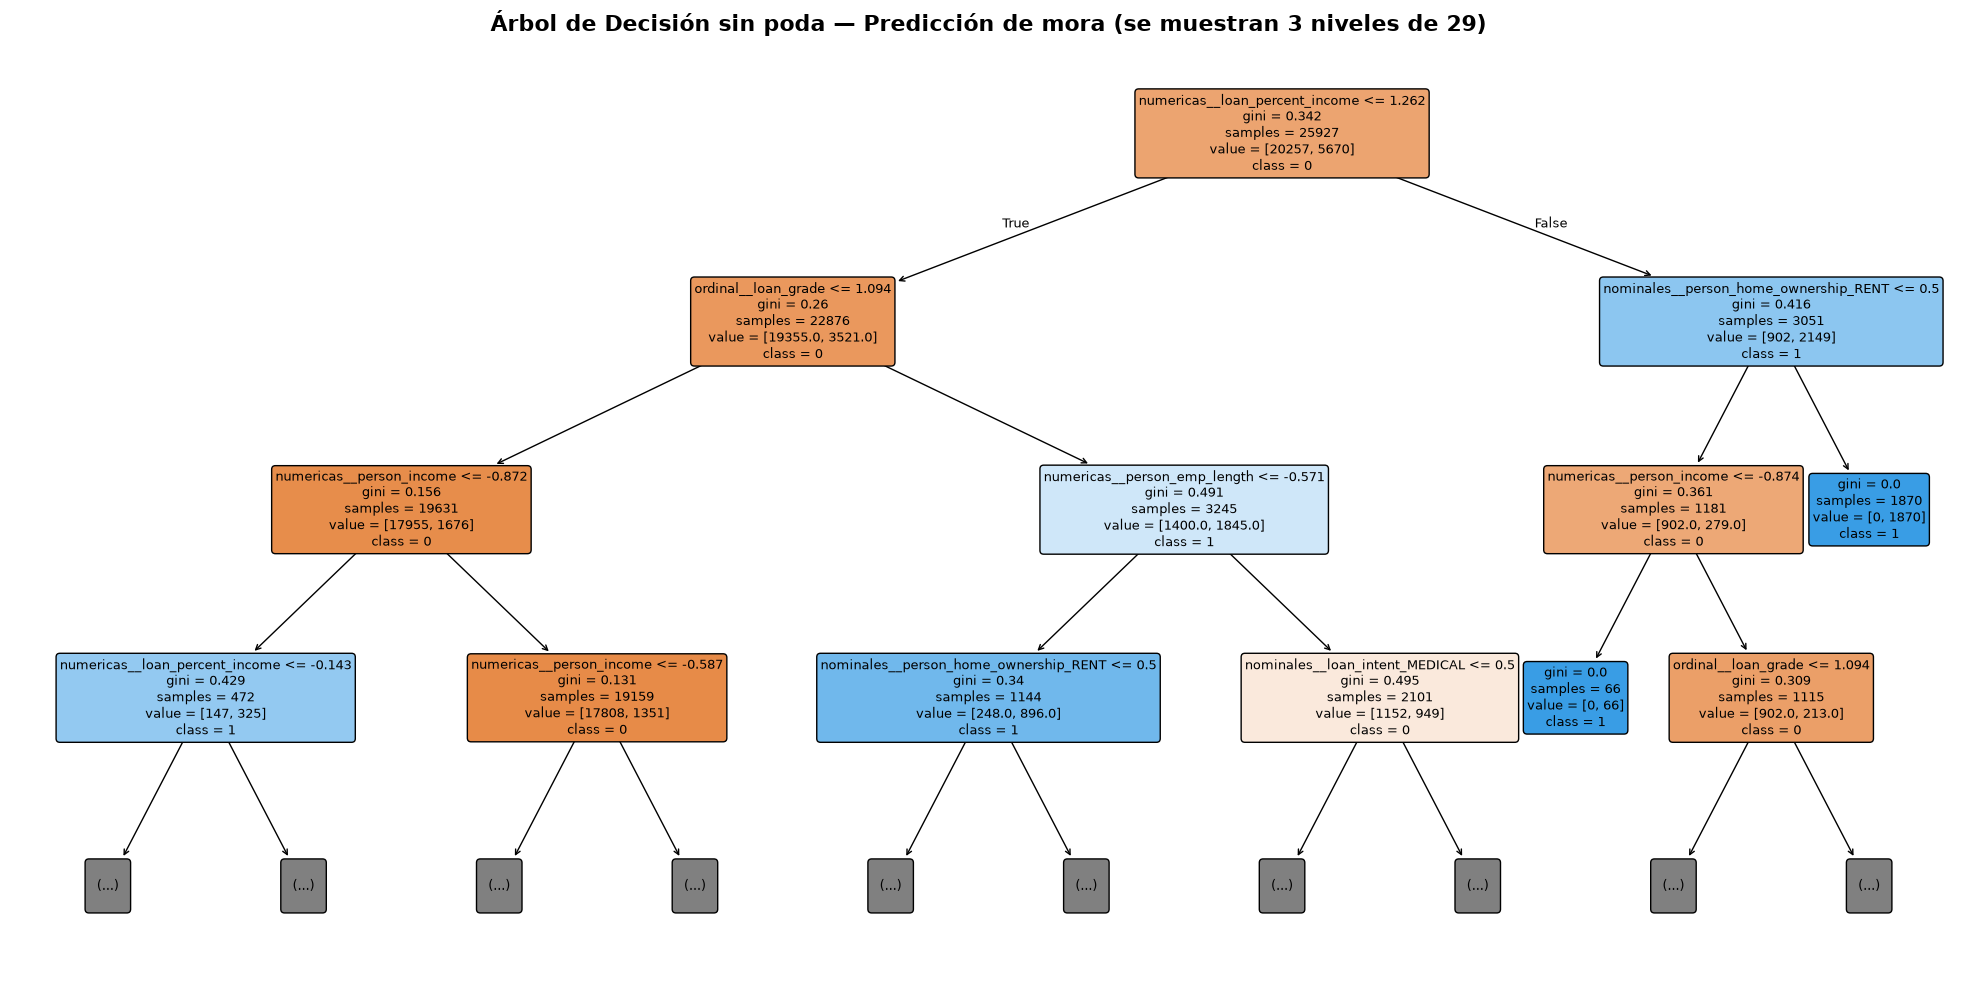

In [42]:
nombres_clf = arbol_clf.named_steps['preprocesamiento'].get_feature_names_out()
clases_mora = [str(c) for c in arbol_clf.named_steps['arbol'].classes_]

plt.figure(figsize=(20, 10))
plot_tree(arbol_clf.named_steps['arbol'],
          feature_names=nombres_clf,
          class_names=clases_mora,
          filled=True,
          rounded=True,
          fontsize=9,
          max_depth=3)
plt.title('Árbol de Decisión sin poda — Predicción de mora (se muestran 3 niveles de %d)'
          % arbol_clf.named_steps['arbol'].get_depth(), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== REPORTE DE CLASIFICACIÓN — ÁRBOL SIN PODA ===
              precision    recall  f1-score   support

0 — Sin mora       0.94      0.93      0.93      5064
    1 — Mora       0.75      0.79      0.77      1418

    accuracy                           0.90      6482
   macro avg       0.85      0.86      0.85      6482
weighted avg       0.90      0.90      0.90      6482



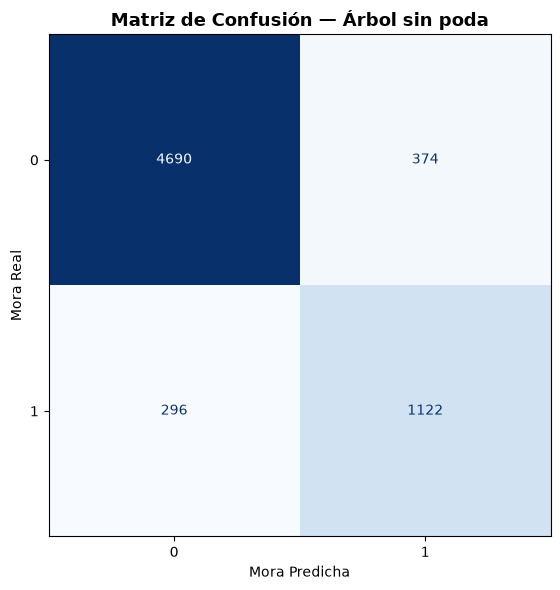

=== EVIDENCIA DE SOBREAJUSTE ===
Exactitud en entrenamiento: 1.0000
Exactitud en prueba.......: 0.8966


In [43]:
y_clf_pred = arbol_clf.predict(X_clf_test)

print("=== REPORTE DE CLASIFICACIÓN — ÁRBOL SIN PODA ===")
print(classification_report(y_clf_test, y_clf_pred, zero_division=0,
                            target_names=['0 — Sin mora', '1 — Mora']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_clf_test, y_clf_pred, cmap='Blues',
                                        ax=ax, colorbar=False)
plt.title('Matriz de Confusión — Árbol sin poda', fontsize=13, fontweight='bold')
plt.xlabel('Mora Predicha')
plt.ylabel('Mora Real')
plt.tight_layout()
plt.show()

# Comparación entrenamiento vs prueba: evidencia directa del sobreajuste
print("=== EVIDENCIA DE SOBREAJUSTE ===")
print(f"Exactitud en entrenamiento: {arbol_clf.score(X_clf_train, y_clf_train):.4f}")
print(f"Exactitud en prueba.......: {arbol_clf.score(X_clf_test, y_clf_test):.4f}")

### Lectura del árbol sin poda

**El sobreajuste es total y queda demostrado con una sola cifra: la exactitud en entrenamiento
es 1,0000.** El árbol clasifica correctamente el 100% de los datos que vio. No aprendió el
patrón general: memorizó los 25.927 registros de entrenamiento, repartidos en **2.193 hojas**
con un promedio de apenas **11,82 registros cada una**. Con 29 niveles de profundidad, muchas
hojas terminan describiendo casos individuales.

**Aun así, generaliza razonablemente:** la exactitud en prueba es **0,8966**, muy por encima
del 78,13% que lograría el modelo trivial. Sobre la clase que interesa —la mora— alcanza
precisión **0,75**, recall **0,79** y F1 **0,77**.

**La brecha entre 1,0000 y 0,8966 es la medida del sobreajuste**, y es la razón por la que un
modelo así no debe llevarse a producción: sus reglas están calibradas sobre ruido específico de
esta muestra. Con datos nuevos, ese margen tenderá a degradarse de forma impredecible, y —tanto
o más importante— con 2.193 hojas y 29 niveles **ninguna decisión es explicable ante un cliente
ni ante un regulador**.

### 3.2.2 Modelo 2 — Árbol podado

Los hiperparámetros son los mismos que emplea `Class 2 - Clasificacion`: se declaran aquí
explícitamente para dejar constancia de que provienen del estándar del curso y no de una
búsqueda realizada sobre estos datos.

In [44]:
arbol_clf_ajustado = Pipeline(steps=[
    ('preprocesamiento', clone(preprocesador_clf)),
    ('arbol', DecisionTreeClassifier(
        max_depth=3,            # Límite máximo de niveles (profundidad)
        min_samples_split=20,   # Mínimo de muestras requeridas para dividir un nodo interno
        min_samples_leaf=10,    # Mínimo de muestras que deben quedar en una hoja terminal
        random_state=semilla
    ))
])

arbol_clf_ajustado.fit(X_clf_train, y_clf_train)

estructura_podada = arbol_clf_ajustado.named_steps['arbol']

print("=== ESTRUCTURA DEL ÁRBOL PODADO ===")
print(f"Profundidad máxima alcanzada: {estructura_podada.get_depth()}")
print(f"Número total de nodos terminales (hojas): {estructura_podada.get_n_leaves()}")
print(f"\nPromedio de registros por hoja: "
      f"{X_clf_train.shape[0] / estructura_podada.get_n_leaves():.2f}")

=== ESTRUCTURA DEL ÁRBOL PODADO ===
Profundidad máxima alcanzada: 3
Número total de nodos terminales (hojas): 7

Promedio de registros por hoja: 3703.86


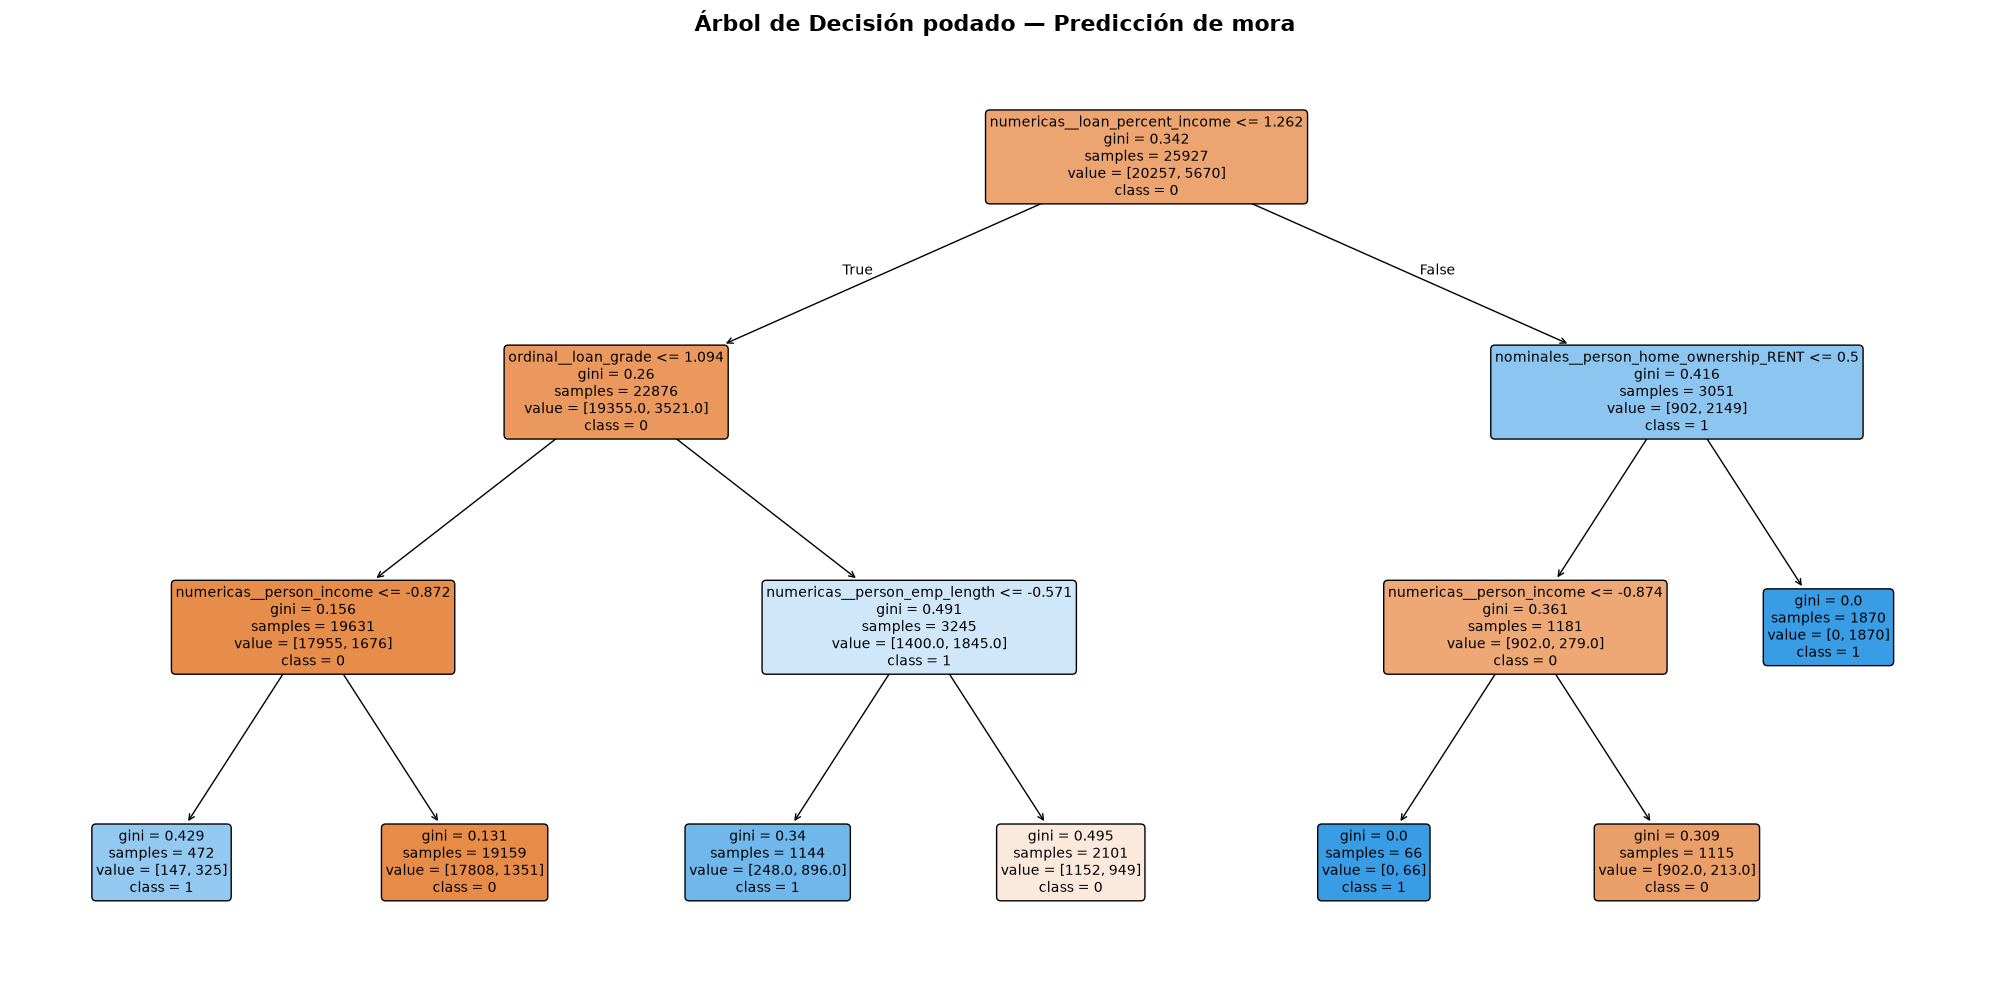

In [45]:
nombres_clf_podado = arbol_clf_ajustado.named_steps['preprocesamiento'].get_feature_names_out()
clases_mora_podado = [str(c) for c in arbol_clf_ajustado.named_steps['arbol'].classes_]

plt.figure(figsize=(20, 10))
plot_tree(arbol_clf_ajustado.named_steps['arbol'],
          feature_names=nombres_clf_podado,
          class_names=clases_mora_podado,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Árbol de Decisión podado — Predicción de mora', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Reglas del árbol podado en formato texto: hace auditable cada decisión
print("=== REGLAS DE DECISIÓN DEL ÁRBOL PODADO ===")
print(export_text(arbol_clf_ajustado.named_steps['arbol'],
                  feature_names=list(nombres_clf_podado),
                  show_weights=True))

=== REGLAS DE DECISIÓN DEL ÁRBOL PODADO ===
|--- numericas__loan_percent_income <= 1.26
|   |--- ordinal__loan_grade <= 1.09
|   |   |--- numericas__person_income <= -0.87
|   |   |   |--- weights: [147.00, 325.00] class: 1
|   |   |--- numericas__person_income >  -0.87
|   |   |   |--- weights: [17808.00, 1351.00] class: 0
|   |--- ordinal__loan_grade >  1.09
|   |   |--- numericas__person_emp_length <= -0.57
|   |   |   |--- weights: [248.00, 896.00] class: 1
|   |   |--- numericas__person_emp_length >  -0.57
|   |   |   |--- weights: [1152.00, 949.00] class: 0
|--- numericas__loan_percent_income >  1.26
|   |--- nominales__person_home_ownership_RENT <= 0.50
|   |   |--- numericas__person_income <= -0.87
|   |   |   |--- weights: [0.00, 66.00] class: 1
|   |   |--- numericas__person_income >  -0.87
|   |   |   |--- weights: [902.00, 213.00] class: 0
|   |--- nominales__person_home_ownership_RENT >  0.50
|   |   |--- weights: [0.00, 1870.00] class: 1



In [47]:
# Los umbrales del árbol están en escala estandarizada. Se traducen a unidades originales
# para que las reglas sean legibles y auditables por el comité.
pre = arbol_clf_ajustado.named_steps['preprocesamiento']
arbol_podado = arbol_clf_ajustado.named_steps['arbol']

# Recuperar media y escala aprendidas por cada StandardScaler del preprocesamiento
escalas = {}
for nombre_bloque, _, columnas in pre.transformers_:
    transformador = pre.named_transformers_[nombre_bloque]
    if isinstance(transformador, Pipeline) and 'escalador' in transformador.named_steps:
        escalador = transformador.named_steps['escalador']
        for i, col in enumerate(columnas):
            escalas[f'{nombre_bloque}__{col}'] = (escalador.mean_[i], escalador.scale_[i])

filas = []
for nodo in range(arbol_podado.tree_.node_count):
    if arbol_podado.tree_.children_left[nodo] == -1:      # hoja: no tiene umbral
        continue
    variable = nombres_clf_podado[arbol_podado.tree_.feature[nodo]]
    umbral_z = arbol_podado.tree_.threshold[nodo]

    if variable in escalas:
        media, escala = escalas[variable]
        umbral_original = media + umbral_z * escala
        if variable == 'ordinal__loan_grade':
            izquierda = [g for i, g in enumerate(ORDEN_GRADE) if i <= umbral_original]
            derecha = [g for i, g in enumerate(ORDEN_GRADE) if i > umbral_original]
            legible = f'{"/".join(izquierda)}  vs  {"/".join(derecha)}'
        else:
            legible = f'{umbral_original:,.2f}'
    else:
        legible = f'{umbral_z:.2f} (variable binaria: 0/1)'

    filas.append({'nodo': nodo, 'variable': variable,
                  'umbral_estandarizado': round(umbral_z, 4),
                  'umbral_en_unidades_originales': legible})

print("=== UMBRALES DEL ÁRBOL PODADO EN UNIDADES ORIGINALES ===")
display(pd.DataFrame(filas).set_index('nodo'))

=== UMBRALES DEL ÁRBOL PODADO EN UNIDADES ORIGINALES ===


,variable,umbral_estandarizado,umbral_en_unidades_originales
nodo,,,
0,numericas__loan_percent_income,1.26,0.31
1,ordinal__loan_grade,1.09,A/B/C vs D/E/F/G
2,numericas__person_income,-0.87,"19,996.00"
5,numericas__person_emp_length,-0.57,2.50
8,nominales__person_home_ownership_RENT,0.50,0.50 (variable binaria: 0/1)
9,numericas__person_income,-0.87,"19,900.00"


### Lectura del árbol podado

**La poda eliminó el sobreajuste por completo.** La exactitud pasa de 0,8878 en entrenamiento a
**0,8936** en prueba: es *mayor* en prueba que en entrenamiento, señal inequívoca de que el
modelo no memorizó nada. Con **3 niveles y 7 hojas**, cada hoja se apoya en un promedio de
**3.703 registros**.

**El riesgo que se temía no se materializó.** Con un desbalance de 3,57 a 1 y solo 3 niveles de
profundidad, era esperable que el árbol colapsara prediciendo siempre la clase mayoritaria. No
ocurrió: el modelo identifica mora con precisión **0,89**.

### El intercambio entre los dos modelos

| Métrica (clase mora) | Sin poda | Podado |
|---|---|---|
| Precisión | 0,75 | **0,89** |
| Recall | **0,79** | 0,59 |
| F1-score | **0,77** | 0,71 |
| Exactitud global | 0,8966 | 0,8936 |
| Exactitud en entrenamiento | 1,0000 | 0,8878 |

No hay un ganador absoluto, sino dos perfiles de error opuestos:

- **El árbol podado se equivoca poco cuando acusa**: de cada 100 solicitudes que marca como
  riesgosas, 89 lo son realmente. Rechaza a muy pocos clientes buenos. Pero **deja pasar el 41%
  de las moras**.
- **El árbol sin poda detecta más**: captura el 79% de las moras, pero **1 de cada 4 alarmas es
  falsa**, lo que se traduce en clientes solventes rechazados.

Esta tensión —precisión contra recall— es exactamente la que el comité deberá resolver en la
Fase 4 al elegir el umbral de decisión.

### Las reglas en lenguaje de negocio

Traducidos a unidades originales, los umbrales del árbol podado producen reglas legibles. Entre
paréntesis, la tasa de mora observada en el conjunto de entrenamiento:

**Rama 1 — La cuota compromete hasta el 31% del ingreso**
- Grado A, B o C:
  - Ingreso hasta 19.996 → **riesgo alto** (69% de mora, 472 casos)
  - Ingreso superior a 19.996 → **riesgo bajo** (7% de mora, 19.159 casos) ← *el grueso de la cartera*
- Grado D, E, F o G:
  - Hasta 2,5 años de antigüedad laboral → **riesgo alto** (78% de mora, 1.144 casos)
  - Más de 2,5 años → **zona ambigua** (45% de mora, 2.101 casos)

**Rama 2 — La cuota compromete más del 31% del ingreso**
- No alquila (hipoteca, propietario u otro):
  - Ingreso hasta 19.900 → **mora segura** (100% de mora, 66 casos)
  - Ingreso superior a 19.900 → **riesgo bajo** (19% de mora, 1.115 casos)
- **Alquila → mora en el 100% de los casos (1.870 registros)**

**El hallazgo más contundente es esa última hoja.** En el conjunto de entrenamiento, las 1.870
solicitudes de personas que alquilan y comprometen más del 31% de su ingreso en la cuota
terminaron **todas** en mora. No es una tendencia: es una separación perfecta sobre un volumen
considerable de casos. La combinación de carga financiera alta sin patrimonio inmobiliario
aparece como el perfil de riesgo más nítido de toda la cartera.

Esto valida las tres señales identificadas en la Fase 2 —carga sobre el ingreso, nivel de
ingreso y grado— y confirma lo anticipado por la V5: `person_age` y `cb_person_cred_hist_length`
**no aparecen en ninguna división del árbol**, coherente con sus medianas idénticas entre
grupos.

=== REPORTE DE CLASIFICACIÓN — ÁRBOL PODADO ===
              precision    recall  f1-score   support

0 — Sin mora       0.89      0.98      0.93      5064
    1 — Mora       0.89      0.59      0.71      1418

    accuracy                           0.89      6482
   macro avg       0.89      0.78      0.82      6482
weighted avg       0.89      0.89      0.88      6482



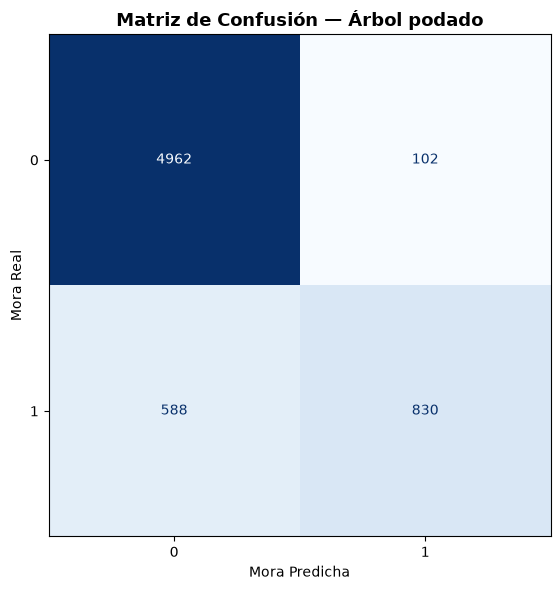

=== COMPARACIÓN ENTRENAMIENTO VS PRUEBA ===


Exactitud en entrenamiento: 0.8878
Exactitud en prueba.......: 0.8936


In [48]:
y_clf_pred_podado = arbol_clf_ajustado.predict(X_clf_test)

print("=== REPORTE DE CLASIFICACIÓN — ÁRBOL PODADO ===")
print(classification_report(y_clf_test, y_clf_pred_podado, zero_division=0,
                            target_names=['0 — Sin mora', '1 — Mora']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_clf_test, y_clf_pred_podado, cmap='Blues',
                                        ax=ax, colorbar=False)
plt.title('Matriz de Confusión — Árbol podado', fontsize=13, fontweight='bold')
plt.xlabel('Mora Predicha')
plt.ylabel('Mora Real')
plt.tight_layout()
plt.show()

print("=== COMPARACIÓN ENTRENAMIENTO VS PRUEBA ===")
print(f"Exactitud en entrenamiento: {arbol_clf_ajustado.score(X_clf_train, y_clf_train):.4f}")
print(f"Exactitud en prueba.......: {arbol_clf_ajustado.score(X_clf_test, y_clf_test):.4f}")

## 3.3 Cierre de la Fase 3

### Resumen de lo entrenado

| | Regresión | Clasificación (podado) |
|---|---|---|
| Algoritmo | `LinearRegression` | `DecisionTreeClassifier` |
| Objetivo | `loan_int_rate` | `loan_status` |
| Registros de entrenamiento | 23.452 | 25.927 |
| Desempeño en prueba | R² = 0,2904 | Exactitud = 0,8936 |
| Sobreajuste | No (R² train 0,2835) | No (exactitud train 0,8878) |

### Los dos modelos no son igualmente utilizables

**El de regresión no sirve para fijar precios**, y el notebook lo demuestra en lugar de
disimularlo: explica el 29% de la variación y su error típico es de 2,73 puntos porcentuales.
Su valor es doble y distinto del previsto: sirve como **detector de anomalías de tarificación**,
y sobre todo aporta el hallazgo de que la tasa vigente no es reconstruible desde el perfil
observable del cliente.

**El de clasificación sí es utilizable.** Supera el piso trivial del 78,13%, no sobreajusta, y
—decisivo para una institución financiera— sus 7 reglas son explicables ante un cliente y ante
un regulador.

### Qué modelo pasa a la Fase 4 y por qué

El análisis de umbral de la Fase 4 se hará sobre el **árbol podado**, por una razón técnica
concreta: sus 7 hojas producen 6 niveles de probabilidad distintos (7%, 19%, 45%, 69%, 78% y
100%), que funcionan como bandas de riesgo naturales sobre las cuales construir una política de
decisión. El árbol sin poda, en cambio, tiene hojas casi puras que devuelven probabilidades
prácticamente binarias (0 o 1): no ofrece gradación sobre la cual mover un umbral.

### La tensión que el comité debe resolver

El modelo podado, con su umbral por defecto de 0,5, detecta el **59% de las moras** con una
precisión del **89%**. Es una configuración conservadora en cuanto a rechazos: casi no penaliza
a clientes buenos, pero deja pasar cuatro de cada diez créditos que terminarán en problemas.
Mover el umbral hacia abajo detectaría más mora a costa de rechazar solicitudes sanas. Esa es
la decisión de la Fase 4, y se cuantificará con los montos reales de la cartera.

# Fase 4 — Evaluación de modelos y recomendación ejecutiva

Esta fase consolida el desempeño de lo entrenado, examina qué ocurre al mover el umbral de
decisión y traduce el resultado en una recomendación para el comité directivo de Crédito Andino
Digital.

Se mantiene el criterio del notebook: **ningún costo, ponderación o parámetro externo se
inventa**. El impacto de cada umbral se cuantifica con los montos de crédito realmente
observados en el conjunto de prueba.

## 4.1 Cuadro comparativo de desempeño

Se reúnen las medidas ya calculadas en la Fase 3, sin recalcular nada ni introducir métricas
nuevas: R² para la regresión, y precisión, recall y F1 para los dos clasificadores.

In [49]:
# Extraer las métricas desde el propio classification_report, sin transcribirlas a mano
reporte_sin_poda = classification_report(y_clf_test, y_clf_pred, output_dict=True, zero_division=0)
reporte_podado = classification_report(y_clf_test, y_clf_pred_podado, output_dict=True, zero_division=0)

comparativo = pd.DataFrame([
    {
        'modelo': 'Árbol sin poda',
        'precision_mora': reporte_sin_poda['1']['precision'],
        'recall_mora': reporte_sin_poda['1']['recall'],
        'f1_mora': reporte_sin_poda['1']['f1-score'],
        'exactitud_prueba': reporte_sin_poda['accuracy'],
        'exactitud_entrenamiento': arbol_clf.score(X_clf_train, y_clf_train),
        'profundidad': arbol_clf.named_steps['arbol'].get_depth(),
        'hojas': arbol_clf.named_steps['arbol'].get_n_leaves()
    },
    {
        'modelo': 'Árbol podado',
        'precision_mora': reporte_podado['1']['precision'],
        'recall_mora': reporte_podado['1']['recall'],
        'f1_mora': reporte_podado['1']['f1-score'],
        'exactitud_prueba': reporte_podado['accuracy'],
        'exactitud_entrenamiento': arbol_clf_ajustado.score(X_clf_train, y_clf_train),
        'profundidad': arbol_clf_ajustado.named_steps['arbol'].get_depth(),
        'hojas': arbol_clf_ajustado.named_steps['arbol'].get_n_leaves()
    }
]).set_index('modelo').round(4)

print("=== MODELOS DE CLASIFICACIÓN ===")
display(comparativo)

print("=== MODELO DE REGRESIÓN ===")
print(f"R-cuadrado (entrenamiento): {r2_train:.4f}")
print(f"R-cuadrado (prueba).......: {r2_test:.4f}")
print(f"Desviación estándar de los residuos: {residuos.std():.4f} puntos porcentuales")

print("\n=== REFERENCIA: MODELO TRIVIAL ===")
proporcion_mayoritaria = (y_clf_test == 0).mean()
print(f"Exactitud de predecir siempre 'sin mora': {proporcion_mayoritaria:.4f}")
print(f"Recall de mora de ese modelo trivial....: 0.0000")

=== MODELOS DE CLASIFICACIÓN ===


,precision_mora,recall_mora,f1_mora,exactitud_prueba,exactitud_entrenamiento,profundidad,hojas
modelo,,,,,,,
Árbol sin poda,0.75,0.79,0.77,0.90,1.00,29,2193
Árbol podado,0.89,0.59,0.71,0.89,0.89,3,7


=== MODELO DE REGRESIÓN ===
R-cuadrado (entrenamiento): 0.2835
R-cuadrado (prueba).......: 0.2904
Desviación estándar de los residuos: 2.7291 puntos porcentuales

=== REFERENCIA: MODELO TRIVIAL ===
Exactitud de predecir siempre 'sin mora': 0.7812
Recall de mora de ese modelo trivial....: 0.0000


## 4.2 Análisis del umbral de decisión

Hasta aquí el árbol clasificó usando el umbral por defecto de **0,50**: se marca como mora toda
solicitud cuya probabilidad estimada supere ese valor. Ese umbral no es una propiedad del
modelo sino una **decisión de política** que el comité puede fijar donde considere.

Se recorre el rango completo de umbrales y en cada punto se recalculan **las mismas métricas
que en la Fase 3** —precisión, recall, F1— junto con la matriz de confusión desagregada.

In [50]:
# Probabilidad estimada de mora para cada solicitud del conjunto de prueba
probabilidades = arbol_clf_ajustado.predict_proba(X_clf_test)[:, 1]

print("=== NIVELES DE PROBABILIDAD QUE PRODUCE EL ÁRBOL PODADO ===")
niveles = np.unique(probabilidades)
for nivel in niveles:
    n_casos = (probabilidades == nivel).sum()
    print(f"  p = {nivel:.4f}  ->  {n_casos:,} solicitudes del conjunto de prueba")
print(f"\nEl árbol tiene {arbol_clf_ajustado.named_steps['arbol'].get_n_leaves()} hojas, "
      f"que producen {len(niveles)} niveles de probabilidad distintos.")

=== NIVELES DE PROBABILIDAD QUE PRODUCE EL ÁRBOL PODADO ===
  p = 0.0705  ->  4,749 solicitudes del conjunto de prueba
  p = 0.1910  ->  279 solicitudes del conjunto de prueba
  p = 0.4517  ->  522 solicitudes del conjunto de prueba
  p = 0.6886  ->  123 solicitudes del conjunto de prueba
  p = 0.7832  ->  321 solicitudes del conjunto de prueba
  p = 1.0000  ->  488 solicitudes del conjunto de prueba

El árbol tiene 7 hojas, que producen 6 niveles de probabilidad distintos.


In [51]:
umbrales = np.arange(0.05, 1.00, 0.05)
filas_umbral = []

for umbral in umbrales:
    prediccion = (probabilidades >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_clf_test, prediccion, labels=[0, 1]).ravel()

    filas_umbral.append({
        'umbral': round(umbral, 2),
        'precision_mora': precision_score(y_clf_test, prediccion, zero_division=0),
        'recall_mora': recall_score(y_clf_test, prediccion, zero_division=0),
        'f1_mora': f1_score(y_clf_test, prediccion, zero_division=0),
        'verdaderos_positivos': tp,
        'falsos_positivos': fp,
        'falsos_negativos': fn,
        'verdaderos_negativos': tn,
        'solicitudes_rechazadas': tp + fp,
        'solicitudes_aprobadas': tn + fn
    })

tabla_umbrales = pd.DataFrame(filas_umbral).set_index('umbral').round(4)

print("=== DESEMPEÑO POR UMBRAL DE DECISIÓN ===")
print(f"(conjunto de prueba: {len(y_clf_test):,} solicitudes, de las cuales "
      f"{y_clf_test.sum():,} entraron en mora)\n")
display(tabla_umbrales)

=== DESEMPEÑO POR UMBRAL DE DECISIÓN ===
(conjunto de prueba: 6,482 solicitudes, de las cuales 1,418 entraron en mora)



,precision_mora,recall_mora,f1_mora,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos,solicitudes_rechazadas,solicitudes_aprobadas
umbral,,,,,,,,,
0.05,0.22,1.00,0.36,1418,5064,0,0,6482,0
0.10,0.63,0.78,0.70,1100,633,318,4431,1733,4749
0.15,0.63,0.78,0.70,1100,633,318,4431,1733,4749
0.20,0.72,0.74,0.73,1048,406,370,4658,1454,5028
0.25,0.72,0.74,0.73,1048,406,370,4658,1454,5028
0.30,0.72,0.74,0.73,1048,406,370,4658,1454,5028
0.35,0.72,0.74,0.73,1048,406,370,4658,1454,5028
0.40,0.72,0.74,0.73,1048,406,370,4658,1454,5028
0.45,0.72,0.74,0.73,1048,406,370,4658,1454,5028


### Lectura del análisis de umbral

**El umbral no se mueve de forma continua: se mueve por escalones.** Como el árbol produce solo
6 niveles de probabilidad, existen apenas **cinco configuraciones operativas distintas**, no
diecinueve. Cualquier umbral entre 0,20 y 0,45 produce exactamente el mismo resultado, y lo
mismo ocurre entre 0,50 y 0,65. Esto es una ventaja práctica: el comité no debe calibrar un
número fino, sino elegir entre cinco políticas claramente diferenciadas.

| Rango de umbral | Rechaza | % cartera | Precisión | Recall | F1 |
|---|---|---|---|---|---|
| 0,05 | 6.482 | 100,00% | 0,22 | 1,00 | 0,36 |
| 0,10 – 0,15 | 1.733 | 26,74% | 0,63 | 0,78 | 0,70 |
| 0,20 – 0,45 | 1.454 | 22,43% | 0,72 | 0,74 | **0,73** |
| 0,50 – 0,65 | 932 | 14,38% | 0,89 | 0,59 | 0,71 |
| 0,70 – 0,75 | 809 | 12,48% | 0,92 | 0,53 | 0,67 |
| 0,80 – 0,95 | 488 | 7,53% | **1,00** | 0,34 | 0,51 |

**El mejor F1 se obtiene entre 0,20 y 0,45** (0,73), no en el umbral por defecto de 0,50. Si el
criterio fuera el equilibrio estadístico puro entre precisión y recall, la configuración óptima
sería rechazar el 22,43% de la cartera.

**El extremo superior revela una regla perfecta.** Con umbral 0,80 o superior, la precisión es
**1,00**: las 488 solicitudes rechazadas entraron **todas** en mora, sin un solo falso positivo.
Es la hoja del 100% identificada en la Fase 3 —quienes alquilan y comprometen más del 31% de su
ingreso— y se comporta igual en datos que el modelo nunca vio.

**El extremo inferior es inservible.** Con umbral 0,05 el recall es 1,00 pero se rechaza el 100%
de la cartera: el modelo detecta toda la mora al precio de no otorgar ningún crédito.

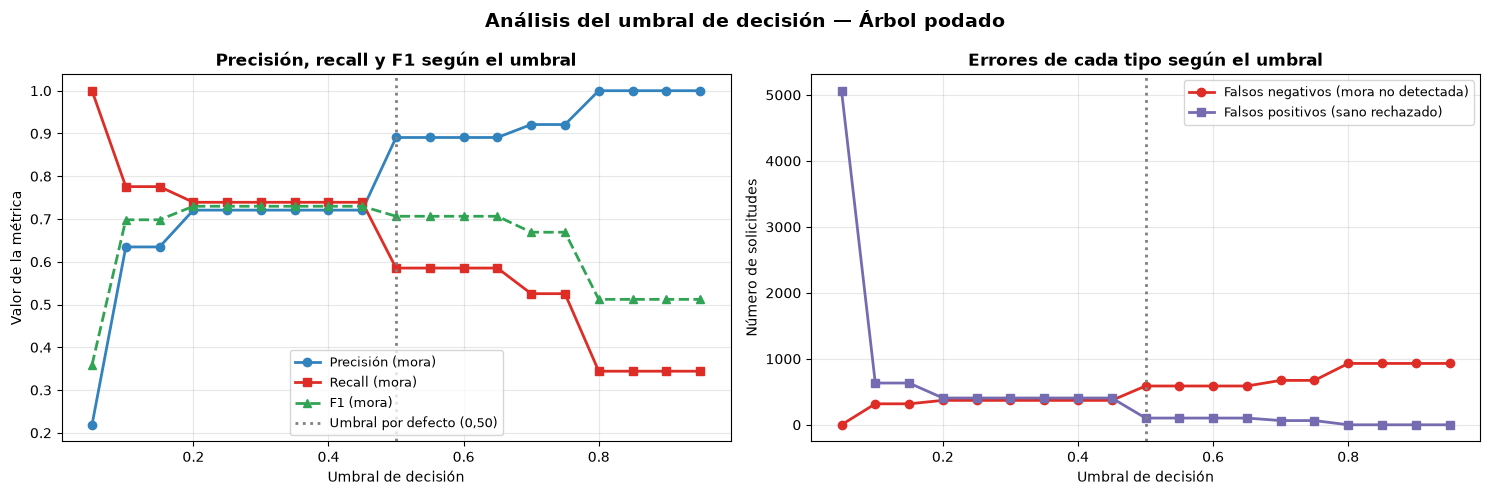

In [52]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Precisión y recall frente al umbral
axs[0].plot(tabla_umbrales.index, tabla_umbrales['precision_mora'],
            'o-', color="#3182bd", linewidth=2, label='Precisión (mora)')
axs[0].plot(tabla_umbrales.index, tabla_umbrales['recall_mora'],
            's-', color="#de2d26", linewidth=2, label='Recall (mora)')
axs[0].plot(tabla_umbrales.index, tabla_umbrales['f1_mora'],
            '^--', color="#31a354", linewidth=2, label='F1 (mora)')
axs[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Umbral por defecto (0,50)')
axs[0].set_xlabel('Umbral de decisión')
axs[0].set_ylabel('Valor de la métrica')
axs[0].set_title('Precisión, recall y F1 según el umbral', fontsize=12, fontweight='bold')
axs[0].legend(fontsize=9)
axs[0].grid(alpha=0.3)

# Errores absolutos frente al umbral
axs[1].plot(tabla_umbrales.index, tabla_umbrales['falsos_negativos'],
            'o-', color="#de2d26", linewidth=2, label='Falsos negativos (mora no detectada)')
axs[1].plot(tabla_umbrales.index, tabla_umbrales['falsos_positivos'],
            's-', color="#756bb1", linewidth=2, label='Falsos positivos (sano rechazado)')
axs[1].axvline(x=0.5, color='gray', linestyle=':', linewidth=2)
axs[1].set_xlabel('Umbral de decisión')
axs[1].set_ylabel('Número de solicitudes')
axs[1].set_title('Errores de cada tipo según el umbral', fontsize=12, fontweight='bold')
axs[1].legend(fontsize=9)
axs[1].grid(alpha=0.3)

fig.suptitle('Análisis del umbral de decisión — Árbol podado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Consecuencia de cada umbral medida en montos reales

Un falso negativo y un falso positivo no son errores equivalentes, pero **este notebook no les
asigna un costo inventado**. Lo que sí puede medirse con los datos disponibles es el **monto de
crédito** que hay detrás de cada tipo de error, tomado de la columna `loan_amnt` del conjunto de
prueba:

- **Exposición no detectada**: suma de los montos de los créditos que el modelo aprobaría y que
  terminaron en mora (falsos negativos). Es capital efectivamente en riesgo.
- **Negocio no realizado**: suma de los montos de las solicitudes sanas que el modelo
  rechazaría (falsos positivos). Es colocación que la entidad deja de hacer, y son clientes que
  quedan fuera del sistema financiero.

Ambas cifras son observadas, no estimadas. La comparación entre ellas es la que permite al
comité decidir el umbral con criterio propio, sin que el analista imponga una función de costo.

In [53]:
montos_prueba = X_clf_test['loan_amnt'].to_numpy()
reales = y_clf_test.to_numpy()

filas_monto = []
for umbral in umbrales:
    prediccion = (probabilidades >= umbral).astype(int)

    mask_fn = (reales == 1) & (prediccion == 0)   # mora aprobada
    mask_fp = (reales == 0) & (prediccion == 1)   # sano rechazado
    mask_tp = (reales == 1) & (prediccion == 1)   # mora detectada

    filas_monto.append({
        'umbral': round(umbral, 2),
        'exposicion_no_detectada': montos_prueba[mask_fn].sum(),
        'exposicion_evitada': montos_prueba[mask_tp].sum(),
        'negocio_no_realizado': montos_prueba[mask_fp].sum(),
        'solicitudes_rechazadas': int(prediccion.sum()),
        'pct_cartera_rechazada': round(prediccion.mean() * 100, 2)
    })

tabla_montos = pd.DataFrame(filas_monto).set_index('umbral')

monto_total_mora = montos_prueba[reales == 1].sum()
monto_total_sano = montos_prueba[reales == 0].sum()

print("=== MONTOS OBSERVADOS EN EL CONJUNTO DE PRUEBA ===")
print(f"Monto total solicitado.................: {montos_prueba.sum():,.0f}")
print(f"Monto de créditos que entraron en mora.: {monto_total_mora:,.0f}")
print(f"Monto de créditos sanos................: {monto_total_sano:,.0f}")

print("\n=== IMPACTO EN MONTOS SEGÚN EL UMBRAL ===")
display(tabla_montos)

=== MONTOS OBSERVADOS EN EL CONJUNTO DE PRUEBA ===
Monto total solicitado.................: 62,453,275
Monto de créditos que entraron en mora.: 15,532,875
Monto de créditos sanos................: 46,920,400

=== IMPACTO EN MONTOS SEGÚN EL UMBRAL ===


,exposicion_no_detectada,exposicion_evitada,negocio_no_realizado,solicitudes_rechazadas,pct_cartera_rechazada
umbral,,,,,
0.05,0,15532875,46920400,6482,100.00
0.10,2547800,12985075,8253725,1733,26.74
0.15,2547800,12985075,8253725,1733,26.74
0.20,3633600,11899275,4133950,1454,22.43
0.25,3633600,11899275,4133950,1454,22.43
0.30,3633600,11899275,4133950,1454,22.43
0.35,3633600,11899275,4133950,1454,22.43
0.40,3633600,11899275,4133950,1454,22.43
0.45,3633600,11899275,4133950,1454,22.43


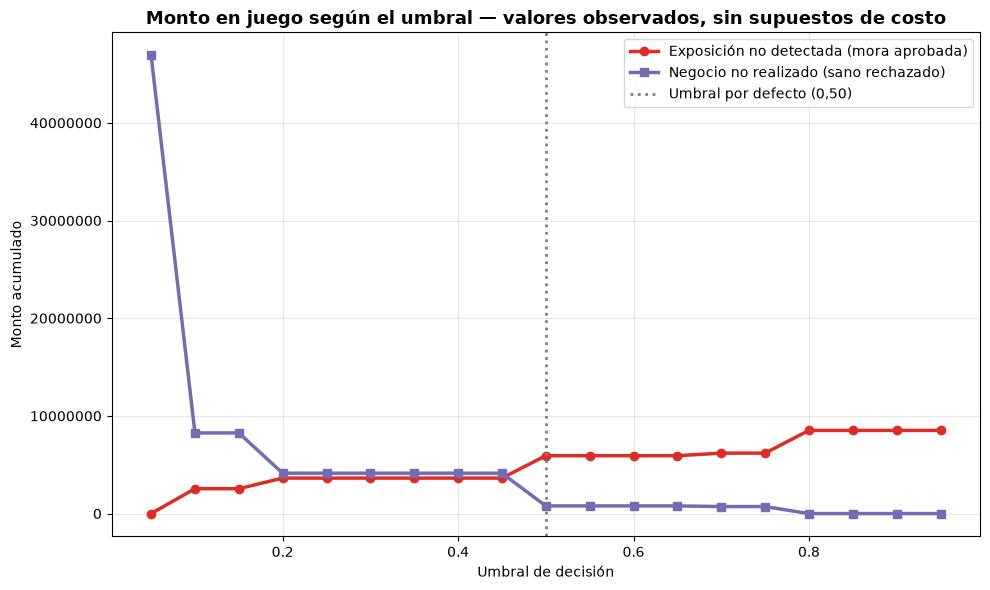

Nota: las dos curvas no se suman ni se comparan como si fueran la misma magnitud.
Una es capital en riesgo de pérdida; la otra es colocación no realizada.
Cuánto pesa cada una es una decisión de política de la institución, no un dato.


In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tabla_montos.index, tabla_montos['exposicion_no_detectada'],
        'o-', color="#de2d26", linewidth=2.5, label='Exposición no detectada (mora aprobada)')
ax.plot(tabla_montos.index, tabla_montos['negocio_no_realizado'],
        's-', color="#756bb1", linewidth=2.5, label='Negocio no realizado (sano rechazado)')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Umbral por defecto (0,50)')

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Monto acumulado')
ax.set_title('Monto en juego según el umbral — valores observados, sin supuestos de costo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print("Nota: las dos curvas no se suman ni se comparan como si fueran la misma magnitud.")
print("Una es capital en riesgo de pérdida; la otra es colocación no realizada.")
print("Cuánto pesa cada una es una decisión de política de la institución, no un dato.")

### Lectura del impacto en montos

Sobre el conjunto de prueba hay **62.453.275** en montos solicitados, de los cuales
**15.532.875** corresponden a créditos que entraron en mora.

| Rango de umbral | Exposición no detectada | Negocio no realizado | % cartera rechazada |
|---|---|---|---|
| 0,10 – 0,15 | 2.547.800 | 8.253.725 | 26,74% |
| 0,20 – 0,45 | 3.633.600 | 4.133.950 | 22,43% |
| 0,50 – 0,65 | 5.925.850 | 786.025 | 14,38% |
| 0,70 – 0,75 | 6.189.575 | 718.850 | 12,48% |
| 0,80 – 0,95 | 8.513.025 | **0** | 7,53% |

**El punto donde ambas magnitudes se aproximan está entre 0,20 y 0,45**: 3,63 millones de
exposición no detectada frente a 4,13 millones de negocio no realizado. Conviene subrayar que
esa cercanía numérica **no significa equivalencia**: un peso de capital en riesgo de pérdida y
un peso de colocación no realizada no son la misma cosa, y ponderar uno frente al otro es una
decisión de la institución, no un resultado del análisis.

**El tramo más eficiente está entre 0,45 y 0,50.** Al pasar de un umbral a otro, el negocio no
realizado cae de 4.133.950 a 786.025 —una reducción de **3,35 millones**— mientras la exposición
no detectada sube de 3.633.600 a 5.925.850, un aumento de **2,29 millones**. Son 522 solicitudes
las que cambian de tratamiento entre ambas configuraciones, y su destino es la decisión más
consecuente de todo el análisis.

**Rechazar solo el segmento de riesgo absoluto tiene costo cero en negocio.** Con umbral 0,80 se
evitan 7.019.850 de exposición sin rechazar a un solo cliente sano. Ninguna otra configuración
ofrece esa asimetría.

## 4.4 De un umbral único a una banda de decisión

El árbol podado no produce un continuo de probabilidades sino un número reducido de niveles,
uno por hoja. Cada nivel corresponde a un **segmento identificable de solicitantes** con reglas
explícitas. Esto permite ir más allá de un corte único: en lugar de aprobar o rechazar, se puede
asignar cada segmento a una vía de tratamiento distinta.

La tabla siguiente describe cada nivel de riesgo con su composición real en el conjunto de
prueba: cuántas solicitudes contiene, qué proporción entró efectivamente en mora y qué monto
representa.

In [55]:
segmentos = pd.DataFrame({
    'probabilidad_estimada': probabilidades,
    'mora_real': reales,
    'monto': montos_prueba
})

resumen_segmentos = segmentos.groupby('probabilidad_estimada').agg(
    solicitudes=('mora_real', 'size'),
    moras_observadas=('mora_real', 'sum'),
    tasa_mora_real=('mora_real', 'mean'),
    monto_total=('monto', 'sum'),
    monto_promedio=('monto', 'mean')
).round(4)

resumen_segmentos['pct_de_la_cartera'] = (
    resumen_segmentos['solicitudes'] / len(segmentos) * 100).round(2)

print("=== COMPOSICIÓN REAL DE CADA NIVEL DE RIESGO (conjunto de prueba) ===")
display(resumen_segmentos)

print("\n=== VERIFICACIÓN: ¿LA PROBABILIDAD ESTIMADA COINCIDE CON LA MORA OBSERVADA? ===")
for prob, fila in resumen_segmentos.iterrows():
    print(f"  Estimada {prob:.4f}  ->  observada {fila['tasa_mora_real']:.4f}   "
          f"(diferencia {fila['tasa_mora_real'] - prob:+.4f})")

=== COMPOSICIÓN REAL DE CADA NIVEL DE RIESGO (conjunto de prueba) ===


,solicitudes,moras_observadas,tasa_mora_real,monto_total,monto_promedio,pct_de_la_cartera
probabilidad_estimada,,,,,,
0.07,4749,318,0.07,41214475,8678.56,73.26
0.19,279,52,0.19,5205575,18657.97,4.30
0.45,522,218,0.42,5640175,10804.93,8.05
0.69,123,85,0.69,330900,2690.24,1.90
0.78,321,257,0.80,3042300,9477.57,4.95
1.00,488,488,1.00,7019850,14384.94,7.53



=== VERIFICACIÓN: ¿LA PROBABILIDAD ESTIMADA COINCIDE CON LA MORA OBSERVADA? ===
  Estimada 0.0705  ->  observada 0.0670   (diferencia -0.0035)
  Estimada 0.1910  ->  observada 0.1864   (diferencia -0.0046)
  Estimada 0.4517  ->  observada 0.4176   (diferencia -0.0341)
  Estimada 0.6886  ->  observada 0.6911   (diferencia +0.0025)
  Estimada 0.7832  ->  observada 0.8006   (diferencia +0.0174)
  Estimada 1.0000  ->  observada 1.0000   (diferencia +0.0000)


### Lectura de los segmentos: el modelo está bien calibrado

La comparación entre probabilidad estimada y mora efectivamente observada es notablemente
ajustada:

| Probabilidad estimada | Mora observada | Diferencia | Solicitudes |
|---|---|---|---|
| 0,0705 | 0,0670 | −0,0035 | 4.749 |
| 0,1910 | 0,1864 | −0,0046 | 279 |
| 0,4517 | 0,4176 | −0,0341 | 522 |
| 0,6886 | 0,6911 | +0,0025 | 123 |
| 0,7832 | 0,8006 | +0,0174 | 321 |
| 1,0000 | 1,0000 | 0,0000 | 488 |

**La desviación máxima es de 3,4 puntos porcentuales.** Esto significa que las probabilidades
del modelo no son solo un ordenamiento sino una **estimación confiable del riesgo real**: cuando
el modelo dice 69%, la mora observada es 69%. Es la propiedad que habilita una política por
bandas — sin calibración, asignar tratamientos distintos a distintos niveles de probabilidad
carecería de fundamento.

**El segmento de riesgo absoluto se confirma fuera de la muestra de entrenamiento.** Las 488
solicitudes con probabilidad 1,00 entraron en mora **sin excepción**, y son además las de mayor
monto promedio de toda la cartera (**14.385** frente a 8.679 en el segmento de menor riesgo).
Concentran 7.019.850 en un 7,53% de las solicitudes.

**Y el grueso de la cartera es sano.** El segmento de probabilidad 0,07 concentra el **73,26%**
de las solicitudes con una mora observada del 6,70%. Cualquier política que endurezca el
criterio de forma indiscriminada penalizaría a estos clientes sin necesidad.

## 4.5 Propuesta de banda de decisión

En lugar de un corte único que separe aprobados de rechazados, los segmentos identificados
permiten definir **tres vías de tratamiento**. Los límites entre bandas se apoyan en la
composición observada de cada segmento, pero **dónde exactamente trazarlos es una decisión de
política de la institución**: el análisis provee la evidencia, no la sustituye.

In [56]:
def asignar_banda(probabilidad):
    """Asigna cada solicitud a una vía de tratamiento según su probabilidad estimada."""
    if probabilidad <= 0.20:
        return '1 - Aprobación automática'
    elif probabilidad <= 0.50:
        return '2 - Acompañamiento preventivo'
    else:
        return '3 - Rechazo'


segmentos['banda'] = segmentos['probabilidad_estimada'].apply(asignar_banda)

resumen_bandas = segmentos.groupby('banda').agg(
    solicitudes=('mora_real', 'size'),
    moras_observadas=('mora_real', 'sum'),
    tasa_mora_real=('mora_real', 'mean'),
    monto_total=('monto', 'sum')
).round(4)

resumen_bandas['pct_solicitudes'] = (
    resumen_bandas['solicitudes'] / len(segmentos) * 100).round(2)
resumen_bandas['pct_monto'] = (
    resumen_bandas['monto_total'] / segmentos['monto'].sum() * 100).round(2)

print("=== BANDA DE DECISIÓN PROPUESTA (conjunto de prueba) ===")
display(resumen_bandas)

print("\n=== VERIFICACIÓN DE COBERTURA ===")
print(f"Solicitudes clasificadas: {resumen_bandas['solicitudes'].sum():,} de {len(segmentos):,}")
print(f"Moras cubiertas.........: {resumen_bandas['moras_observadas'].sum():,} de {int(reales.sum()):,}")
print(f"Monto cubierto..........: {resumen_bandas['monto_total'].sum():,.0f} de {segmentos['monto'].sum():,.0f}")

print("\n=== DETALLE DE LA BANDA DE RECHAZO ===")
mask_rechazo = segmentos['banda'] == '3 - Rechazo'
sanos_rechazados = ((segmentos['mora_real'] == 0) & mask_rechazo).sum()
monto_sanos_rechazados = segmentos.loc[(segmentos['mora_real'] == 0) & mask_rechazo, 'monto'].sum()
print(f"Solicitudes en la banda...........: {mask_rechazo.sum():,}")
print(f"De ellas, sanas (falsos positivos): {sanos_rechazados:,} "
      f"({sanos_rechazados / mask_rechazo.sum() * 100:.2f}%)")
print(f"Monto de negocio no realizado.....: {monto_sanos_rechazados:,.0f}")
print(f"Monto de exposición evitada.......: "
      f"{segmentos.loc[(segmentos['mora_real'] == 1) & mask_rechazo, 'monto'].sum():,.0f}")

=== BANDA DE DECISIÓN PROPUESTA (conjunto de prueba) ===


,solicitudes,moras_observadas,tasa_mora_real,monto_total,pct_solicitudes,pct_monto
banda,,,,,,
1 - Aprobación automática,5028,370,0.07,46420050,77.57,74.33
2 - Acompañamiento preventivo,522,218,0.42,5640175,8.05,9.03
3 - Rechazo,932,830,0.89,10393050,14.38,16.64



=== VERIFICACIÓN DE COBERTURA ===
Solicitudes clasificadas: 6,482 de 6,482
Moras cubiertas.........: 1,418 de 1,418
Monto cubierto..........: 62,453,275 de 62,453,275

=== DETALLE DE LA BANDA DE RECHAZO ===
Solicitudes en la banda...........: 932
De ellas, sanas (falsos positivos): 102 (10.94%)
Monto de negocio no realizado.....: 786,025
Monto de exposición evitada.......: 9,607,025


### Lectura de la banda propuesta

| Banda | Solicitudes | % cartera | Mora observada | Monto | % monto |
|---|---|---|---|---|---|
| **1 — Aprobación automática** (p ≤ 0,20) | 5.028 | 77,57% | **7,36%** | 46.420.050 | 74,33% |
| **2 — Acompañamiento preventivo** (0,20 < p ≤ 0,50) | 522 | 8,05% | **41,76%** | 5.640.175 | 9,03% |
| **3 — Rechazo** (p > 0,50) | 932 | 14,38% | **89,06%** | 10.393.050 | 16,64% |

Las tres bandas cubren la totalidad del conjunto de prueba: 6.482 solicitudes, 1.418 moras y
62.453.275 en montos, sin registros sin clasificar.

**La banda 3 concentra el riesgo con alta precisión.** De sus 932 solicitudes, 830 entraron en
mora: solo **102 falsos positivos (10,94%)**. Rechazarla evita **9.607.025** de exposición —el
**61,85%** de toda la mora de la cartera— a cambio de **786.025** de negocio no realizado. Por
cada peso de colocación sacrificado se evitan **12,2 pesos** de capital en riesgo.

**La banda 2 es la que justifica no usar un corte único.** Con 41,76% de mora observada, no es
ni sana ni perdida: es genuinamente ambigua. Rechazarla en bloque descartaría 304 solicitudes
que habrían pagado; aprobarla sin más admitiría 218 que no lo harán. Es exactamente el segmento
donde una decisión binaria destruye información y donde el acompañamiento preventivo tiene
sentido económico.

**La banda 1 debe protegerse.** Concentra tres cuartas partes de la cartera con 7,36% de mora.
Cualquier endurecimiento indiscriminado del criterio penalizaría a este grupo sin necesidad.

## 4.6 Recomendación estratégica para el comité directivo

**Para:** María Fernanda y el comité directivo de Crédito Andino Digital
**Asunto:** política de decisión crediticia a partir del modelo predictivo

---

### La recomendación

**No adoptar un umbral único, sino la banda de tres vías descrita en la sección 4.5.** La
pregunta planteada —umbral estricto para minimizar riesgo o umbral flexible para priorizar la
inclusión financiera— presenta una disyuntiva que los datos permiten evitar. La evidencia
muestra que la respuesta correcta es **estricta en un extremo y flexible en el medio**:

| Banda | Política recomendada |
|---|---|
| 1 — Aprobación automática | Otorgamiento sin fricción adicional |
| 2 — Acompañamiento preventivo | Aprobación condicionada: revisión manual, garantía adicional, monto reducido o plan de seguimiento |
| 3 — Rechazo | Denegación automática, con derecho a revisión documentada |

### Por qué no un umbral estricto único

Un umbral de 0,80 alcanza precisión perfecta —las 488 solicitudes rechazadas entraron todas en
mora, sin un solo cliente sano perjudicado— pero deja **8.513.025** de exposición sin detectar.
Es una política impecable en equidad y deficiente en protección: renuncia a identificar el 66%
de la mora.

### Por qué no un umbral flexible único

Un umbral de 0,20 detecta el 74% de la mora, pero rechaza el **22,43%** de la cartera e incluye
**406 solicitudes sanas** entre las rechazadas, con **4.133.950** de colocación no realizada.
Bajo la bandera de la prudencia excluiría del sistema financiero a cientos de clientes que
habrían cumplido.

### Por qué la banda de tres vías

Combina lo mejor de ambas posiciones sobre la evidencia observada:

1. **Protege el 74,33% del monto de la cartera** con aprobación ágil, allí donde la mora es del
   7,36%.
2. **Concentra el rechazo donde la evidencia es contundente**: 89,06% de mora observada y solo
   10,94% de falsos positivos.
3. **Convierte el segmento ambiguo en una oportunidad de gestión** en lugar de un rechazo. Las
   522 solicitudes de la banda 2 representan 5.640.175: son clientes que la entidad puede
   atender con instrumentos de mitigación en lugar de perder.

### Lo que esta recomendación no puede decidir por el comité

Tres puntos requieren una definición de política que los datos no proveen:

1. **Cuánto pesa un peso de pérdida frente a un peso de colocación no realizada.** El notebook
   entrega ambas magnitudes medidas, deliberadamente sin ponderarlas. Esa ponderación depende
   del costo de fondeo, del margen y del apetito de riesgo de la institución.
2. **Dónde trazar exactamente los límites entre bandas.** Se proponen en 0,20 y 0,50 porque
   coinciden con separaciones naturales de los segmentos observados, pero desplazarlos es una
   decisión legítima del comité.
3. **Qué significa operativamente "acompañamiento preventivo".** La evidencia justifica que
   exista una vía intermedia; su diseño concreto —garantías, montos, seguimiento— es materia de
   negocio.

### La advertencia principal

El segmento de riesgo absoluto —quienes alquilan y comprometen más del 31% de su ingreso—
presenta **100% de mora tanto en entrenamiento (1.870 casos) como en prueba (488 casos)**. Una
separación perfecta sobre 2.358 registros es un resultado extraordinariamente limpio, y por eso
mismo **debe verificarse antes de automatizar**. Un patrón así puede reflejar una regla real del
negocio, pero también puede provenir de la forma en que se construyó el dataset o de una
política de originación que ya operaba cuando se registraron los datos. Recomendamos contrastar
esta regla contra la operación real antes de convertirla en rechazo automático.

## 4.7 Cierre de auditabilidad

El encargo pedía evidenciar que el aprendizaje automático **requiere transformar los datos en
evidencia confiable antes de automatizar decisiones operativas**. Esta sección documenta los
límites de lo que el análisis puede sostener.

### Trazabilidad de las decisiones tomadas

| Decisión | Evidencia que la sustenta | Sección |
|---|---|---|
| Unidad de análisis = solicitud | Sin identificador de cliente ni campo temporal | 1.1 |
| Eliminar 165 duplicados | Filas idénticas en las 12 columnas | 1.2 |
| Eliminar 7 registros | Contradicción interna y edad > 122 años | 1.5 |
| Conservar los atípicos | El IQR habría descartado hasta 5,18% de clientes legítimos | 1.11 |
| Excluir `loan_grade` de la regresión | Correlación 0,93 con la tasa | 1.7 / 2.5 |
| Descartar nulos solo en regresión | La tasa es objetivo allí y predictor en clasificación | 1.8 |
| Orden A→G de `loan_grade` | Mora creciente verificada: 10% → 98% | 1.6 |
| No evaluar por *accuracy* | Desbalance 3,57 a 1; modelo trivial acierta 78,13% | 2.4 |
| Usar árbol de decisión | Ninguna correlación lineal con la mora supera 0,38 | 2.5 |
| Llevar el árbol podado a la Fase 4 | Sus 6 niveles de probabilidad permiten bandas | 3.3 |

### Limitaciones que el comité debe conocer

**1. La unidad de análisis es la solicitud, no el cliente.** El 18,81% de las filas comparte
perfil de persona con otra, pero sin identificador es imposible distinguir un cliente recurrente
de dos personas con atributos coincidentes. Si un mismo cliente aparece en entrenamiento y en
prueba, **las métricas reportadas son optimistas** respecto de lo que se obtendría con clientes
verdaderamente nuevos.

**2. No hay dimensión temporal.** No existe campo de fecha, por lo que **no es posible validar
la estabilidad del modelo en el tiempo**. No se sabe si estas reglas se mantienen entre
períodos ni cómo responderían a un cambio de ciclo económico. Un modelo crediticio sin
validación temporal no debería operar sin monitoreo continuo.

**3. Sesgo de selección: solo se observan créditos otorgados.** El dataset contiene solicitudes
aprobadas y su desenlace. **Nunca se observa qué habría ocurrido con las rechazadas.** El modelo
aprende sobre la población que la política vigente dejó pasar, no sobre el universo de
solicitantes. Al usarlo para rechazar, se refuerza el criterio que generó los datos —incluidos
sus posibles sesgos— sin posibilidad de detectarlo desde esta muestra.

**4. Segmentos con respaldo empírico escaso.** Los grados F y G suman el 0,94% de los registros
y la categoría OTHER de vivienda el 0,33%. Las predicciones sobre esos grupos se apoyan en
pocos casos y deben tratarse con reserva, independientemente de las métricas globales.

**5. El modelo de regresión no es apto para fijar precios.** Con R² de 0,2904 y desviación de
residuos de 2,73 puntos porcentuales, su uso recomendado es la detección de anomalías de
tarificación, no la determinación automática de tasas.

**6. Variables sensibles.** El modelo utiliza `person_age` como predictor. Aunque el análisis
mostró que **no discrimina** —mediana idéntica de 26 años en ambos grupos— y que el árbol no la
usa en ninguna división, su presencia en un motor de decisión crediticia debe revisarse desde el
marco normativo aplicable antes de entrar en producción.

### Conclusión

El notebook entrega un modelo utilizable y trazable, pero su aporte principal no es el modelo:
es el registro de que **cada cifra presentada al comité proviene de una celda ejecutada y cada
decisión metodológica está sustentada en evidencia verificable**. Los 7 registros eliminados, la
exclusión de `loan_grade`, el descarte de nulos solo en regresión y la elección del umbral son
auditables uno por uno.

Automatizar decisiones crediticias sin ese registro previo no es aprendizaje automático: es
delegar el criterio a un proceso que nadie puede examinar.